<a href="https://colab.research.google.com/github/sp-mujuni/1-Year-MachineLearning-Journey/blob/master/clustering_run_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geospatial Data and Computational  Intelligence Lab

## Clustering the lab's air quality dataset

## 1. Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import silhouette_samples
import os

## 2. Listing files in dataset

In [ ]:
# For Google Colab - mount Google Drive if not already mounted
from google.colab import drive  # type: ignore
drive.mount('/content/drive')
# Update this path to match where your Clustering folder is in Google Drive
dataset_path = '/content/drive/MyDrive/2025/AI/Clustering/clean'
print(f"Using Colab path: {dataset_path}")

print(f"Files in dataset: {os.listdir(dataset_path)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Colab path: /content/drive/MyDrive/2025/AI/Clustering/clean
Files in dataset: ['fantasto_codetect_db_fixed.csv']


## 3. Loading dataset

In [ ]:
df = pd.read_csv(f'{dataset_path}/fantasto_codetect_db_fixed.csv')

## 4. Inspecting the data

In [ ]:
df.describe()

,id,store_id,temperature,humidity,carbondioxide,carbonmonoxide,dust,pollution
count,105246.000000,105246.000000,105246.000000,105246.0,105246.000000,105246.000000,105246.000000,105246.000000
mean,65651.236351,8.000105,0.019184,0.0,649.245473,42.859966,8171.631786,247.339215
std,30382.474122,0.010223,0.764790,0.0,205.294737,18.376314,28796.800217,141.287230
min,13025.000000,8.000000,0.000000,0.0,-26.000000,0.000000,-32768.000000,-66.000000
25%,39340.250000,8.000000,0.000000,0.0,475.000000,36.000000,-30223.000000,128.000000
50%,65651.500000,8.000000,0.000000,0.0,642.000000,40.000000,27497.000000,247.000000
75%,91962.750000,8.000000,0.000000,0.0,828.000000,46.000000,30526.000000,368.000000
max,118274.000000,9.000000,79.000000,0.0,1938.000000,285.000000,32767.000000,500.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105246 entries, 0 to 105245
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   id              105246 non-null  int64 
 1   store_id        105246 non-null  int64 
 2   temperature     105246 non-null  int64 
 3   humidity        105246 non-null  int64 
 4   carbondioxide   105246 non-null  int64 
 5   carbonmonoxide  105246 non-null  int64 
 6   dust            105246 non-null  int64 
 7   pollution       105246 non-null  int64 
 8   created_at      105246 non-null  object
 9   updated_at      105246 non-null  object
dtypes: int64(8), object(2)
memory usage: 8.0+ MB


In [ ]:
df.head()

,id,store_id,temperature,humidity,carbondioxide,carbonmonoxide,dust,pollution,created_at,updated_at
0,19961,8,0,0,320,36,32459,276,2025-04-15 17:43:12,2025-04-15 17:43:12
1,19960,8,0,0,728,36,31829,164,2025-04-15 17:41:52,2025-04-15 17:41:52
2,19959,8,0,0,631,35,32082,30,2025-04-15 17:40:33,2025-04-15 17:40:33
3,19958,8,0,0,788,36,32068,265,2025-04-15 17:39:13,2025-04-15 17:39:13
4,19957,8,0,0,377,35,31462,177,2025-04-15 17:37:54,2025-04-15 17:37:54


In [ ]:
df.tail()

,id,store_id,temperature,humidity,carbondioxide,carbonmonoxide,dust,pollution,created_at,updated_at
105241,118270,8,0,0,886,44,31482,337,2025-09-25 16:58:08,2025-09-25 16:58:08
105242,118271,8,0,0,478,43,30921,276,2025-09-25 16:59:28,2025-09-25 16:59:28
105243,118272,8,0,0,539,44,31166,59,2025-09-25 17:00:47,2025-09-25 17:00:47
105244,118273,8,0,0,957,43,30187,111,2025-09-25 17:02:07,2025-09-25 17:02:07
105245,118274,8,0,0,733,43,30800,84,2025-09-25 17:03:26,2025-09-25 17:03:26


In [ ]:
df.isnull().sum()

,0
id,0
store_id,0
temperature,0
humidity,0
carbondioxide,0
carbonmonoxide,0
dust,0
pollution,0
created_at,0
updated_at,0


In [ ]:
df.shape

(105246, 10)

## 5. Data Cleaning and Pollutant Detection

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.tail()

,id,store_id,temperature,humidity,carbondioxide,carbonmonoxide,dust,pollution,created_at,updated_at
105241,118270,8,0,0,886,44,31482,337,2025-09-25 16:58:08,2025-09-25 16:58:08
105242,118271,8,0,0,478,43,30921,276,2025-09-25 16:59:28,2025-09-25 16:59:28
105243,118272,8,0,0,539,44,31166,59,2025-09-25 17:00:47,2025-09-25 17:00:47
105244,118273,8,0,0,957,43,30187,111,2025-09-25 17:02:07,2025-09-25 17:02:07
105245,118274,8,0,0,733,43,30800,84,2025-09-25 17:03:26,2025-09-25 17:03:26


In [ ]:
df.shape

(105246, 10)

In [ ]:
df.head()

,id,store_id,temperature,humidity,carbondioxide,carbonmonoxide,dust,pollution,created_at,updated_at
0,19961,8,0,0,320,36,32459,276,2025-04-15 17:43:12,2025-04-15 17:43:12
1,19960,8,0,0,728,36,31829,164,2025-04-15 17:41:52,2025-04-15 17:41:52
2,19959,8,0,0,631,35,32082,30,2025-04-15 17:40:33,2025-04-15 17:40:33
3,19958,8,0,0,788,36,32068,265,2025-04-15 17:39:13,2025-04-15 17:39:13
4,19957,8,0,0,377,35,31462,177,2025-04-15 17:37:54,2025-04-15 17:37:54


In [ ]:
# List of pollutants
pollutant_keywords = ['carbondioxide', 'carbonmonoxide', 'dust']

# Automatically detecting pollutant columns
pollutant_cols = [
    col for col in df.columns
    if any(key in col for key in pollutant_keywords)
]

# Checking if any columns were detected
if not pollutant_cols:
    raise ValueError("No pollutant-related columns found in the dataset. Check column names or keyword list.")

print(f"\n Pollutant columns detected: {pollutant_cols}")

# Keeping only pollutant columns and drop the rest
df_pollutants = df[pollutant_cols]

print(f"\nRemaining columns after filtering: {list(df_pollutants.columns)}")


 Pollutant columns detected: ['carbondioxide', 'carbonmonoxide', 'dust']

Remaining columns after filtering: ['carbondioxide', 'carbonmonoxide', 'dust']


In [ ]:
df_pollutants.head()

,carbondioxide,carbonmonoxide,dust
0,320,36,32459
1,728,36,31829
2,631,35,32082
3,788,36,32068
4,377,35,31462


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pollutants)

clf = IsolationForest(contamination=0.02, random_state=42)
df_pollutants['outlier'] = clf.fit_predict(X_scaled)

# Keep only normal observations (outlier = -1 indicates anomaly)
df_clean = df_pollutants[df_pollutants['outlier'] == 1].copy()

/tmp/ipython-input-3970378452.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pollutants['outlier'] = clf.fit_predict(X_scaled)


## 6. Performing feature scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

## 7. Applying K-Means Clustering

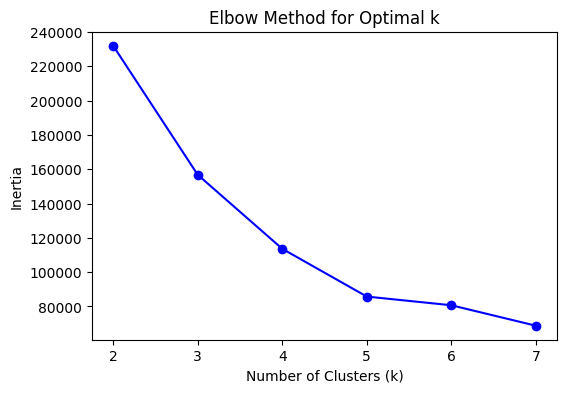

In [ ]:
# Finding the optimal number of clusters using the Elbow Method
inertia = []
K = range(2, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, 'bo-')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [ ]:
# Choosing k = 5
kmeans = KMeans(n_clusters=5, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster counts:")
print(df_clean['Cluster'].value_counts())


Cluster counts:
Cluster
1    33811
0    30490
4    18772
2    17595
3     2473
Name: count, dtype: int64


## 8. Cluster Analysis

In [ ]:
cluster_summary = df_clean.groupby('Cluster')[pollutant_cols].mean()
print("\nCluster Summary (mean pollutant levels):")
display(cluster_summary)


Cluster Summary (mean pollutant levels):


,carbondioxide,carbonmonoxide,dust
Cluster,,,
0,835.162643,38.582880,29400.284454
1,481.378072,38.692851,29416.269528
2,833.034555,41.996022,-30812.227280
3,655.665588,85.295188,21436.997574
4,475.133124,41.789580,-30854.855210


## 9. PCA Visualization

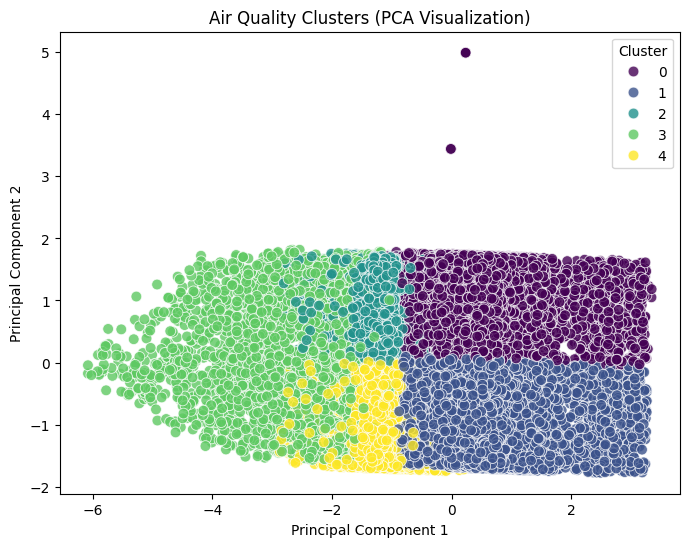

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df_clean['PCA1'] = pca_result[:, 0]
df_clean['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=df_clean,
    s=60, alpha=0.8
)
plt.title('Air Quality Clusters (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

## 10. Pollutant Profile Comparison

<Figure size 1000x600 with 0 Axes>

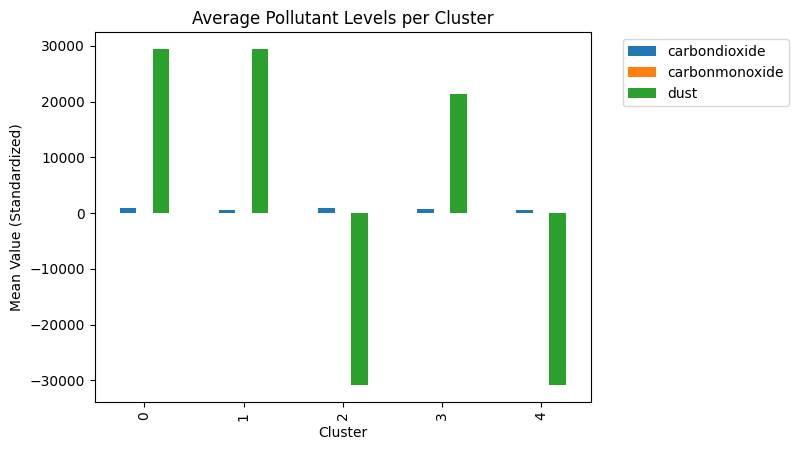

In [ ]:
plt.figure(figsize=(10,6))
cluster_summary.plot(kind='bar')
plt.title("Average Pollutant Levels per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Value (Standardized)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 11. Computing Pollution Severity Score

In [ ]:
# Sum normalized pollutant levels to get a 'pollution score'
pollution_scores = cluster_summary.mean(axis=1)

In [ ]:
# Sorting clusters by severity
sorted_clusters = pollution_scores.sort_values().index.tolist()

In [ ]:
# Assigning qualitative labels
severity_labels = {}
for i, cluster_id in enumerate(sorted_clusters):
    if i == 0:
        severity_labels[cluster_id] = 'Clean Air'
    elif i == 1:
        severity_labels[cluster_id] = 'Moderate Air Quality'
    elif i == 2:
        severity_labels[cluster_id] = 'Poor Air Quality'
    elif i == 3:
        severity_labels[cluster_id] = 'Polluted'
    else:
        severity_labels[cluster_id] = 'Hazardous'

# Add labels to dataframe
df_clean['Severity_Label'] = df_clean['Cluster'].map(severity_labels)

## 12. Visualizing Cluster Severity

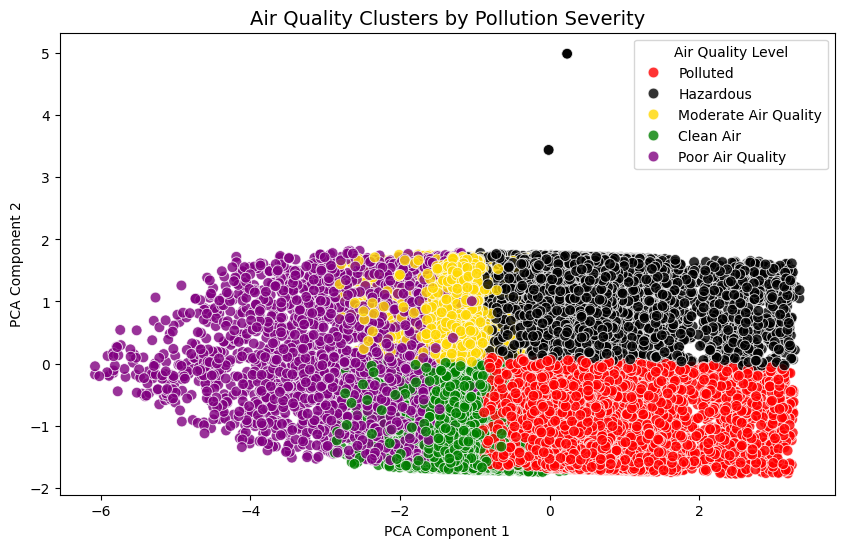

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x='PCA1', y='PCA2',
    hue='Severity_Label',
    palette={'Clean Air': 'green', 'Moderate Air Quality': 'gold', 'Poor Air Quality': 'purple', 'Polluted': 'red', 'Hazardous': 'black'},
    s=60, alpha=0.8
)
plt.title('Air Quality Clusters by Pollution Severity', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Air Quality Level')
plt.show()

## 13. Cluster Temporal Analysis

In [ ]:

# Add timestamp column to df_clean
df_clean['updated_at'] = df['updated_at']

# --- Ensure datetime type ---
df_clean['updated_at'] = pd.to_datetime(df_clean['updated_at'], errors='coerce')
df_clean = df_clean.dropna(subset=['updated_at'])

# --- Extract time features ---
df_clean['month'] = df_clean['updated_at'].dt.to_period('M')
df_clean['week'] = df_clean['updated_at'].dt.isocalendar().week
df_clean['day_name'] = df_clean['updated_at'].dt.day_name()
df_clean['hour'] = df_clean['updated_at'].dt.hour

In [ ]:
# Define time windows
def time_window(hour):
    if 6 <= hour < 9:
        return "6–9 AM"
    elif 9 <= hour < 12:
        return "9–12 PM"
    elif 12 <= hour < 15:
        return "12–3 PM"
    else:
        return None

df_clean['time_window'] = df_clean['hour'].apply(time_window)
df_clean = df_clean.dropna(subset=['time_window'])

# --- Select 2 representative weeks per month ---
weeks_per_month = (
    df_clean.groupby('month')['week']
    .apply(lambda x: pd.Series(x.unique()).sample(min(2, len(x.unique())), random_state=42))
    .explode()
    .reset_index(drop=True)
)

df_sampled = df_clean[df_clean['week'].isin(weeks_per_month)]

In [ ]:
# --- Determine numeric pollutant columns only ---
exclude_cols = {'updated_at','month','week','day_name','hour','time_window','Cluster','Severity_Label','date'}
numeric_cols = df_sampled.select_dtypes(include=[np.number]).columns.tolist()
pollutant_cols = [c for c in numeric_cols if c not in exclude_cols]

# --- Aggregate pollution levels ---
# Ensure month column exists
df_clean['month'] = df_clean['updated_at'].dt.to_period('M')

df_clean['week_in_month'] = (
    df_clean.groupby('month')['week']
    .transform(lambda w: pd.factorize(w)[0] + 1)
)

agg_df = df_clean.groupby(
    ['month', 'week', 'week_in_month', 'day_name', 'time_window']
)[pollutant_cols].mean().reset_index()

# --- Encode temporal features for clustering ---
temporal_encoded = pd.get_dummies(agg_df[['day_name','time_window']], drop_first=True)
features = pd.concat([agg_df[pollutant_cols], temporal_encoded], axis=1)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# --- Perform KMeans temporal clustering ---
kmeans = KMeans(n_clusters=5, random_state=42)
agg_df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
# Get all months in sorted order
months = sorted(df_clean['month'].unique())

selected_rows = []

for i, month in enumerate(months):
    month_df = df_clean[df_clean['month'] == month]

    # Alternating pattern:
    # Month index: 0 → 1&3, 1 → 2&4, 2 → 1&3, 3 → 2&4...
    if i % 2 == 0:
        target_positions = [1, 3]
    else:
        target_positions = [2, 4]

    available_positions = month_df['week_in_month'].unique()
    chosen = [p for p in target_positions if p in available_positions]

    month_selected = month_df[month_df['week_in_month'].isin(chosen)]
    selected_rows.append(month_selected)

df_sampled = pd.concat(selected_rows, ignore_index=True)



 Month: 2025-04


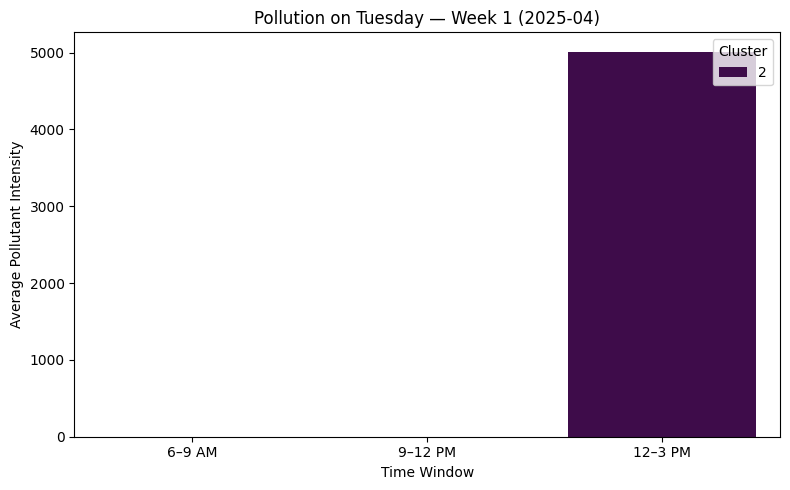

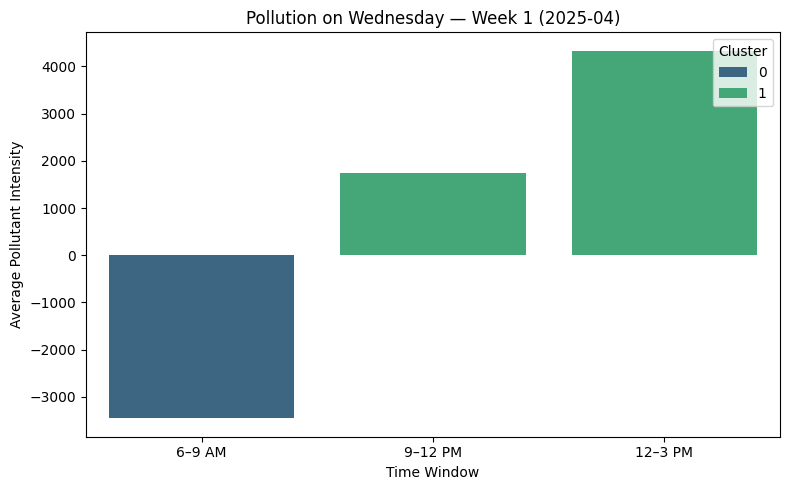

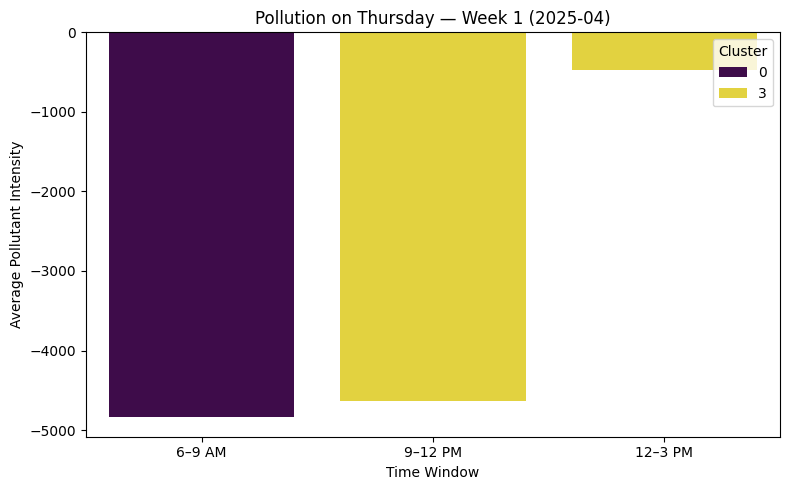

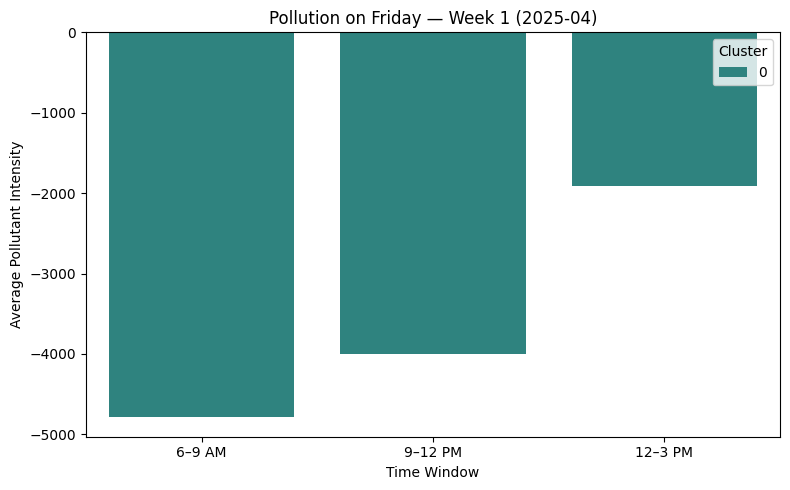

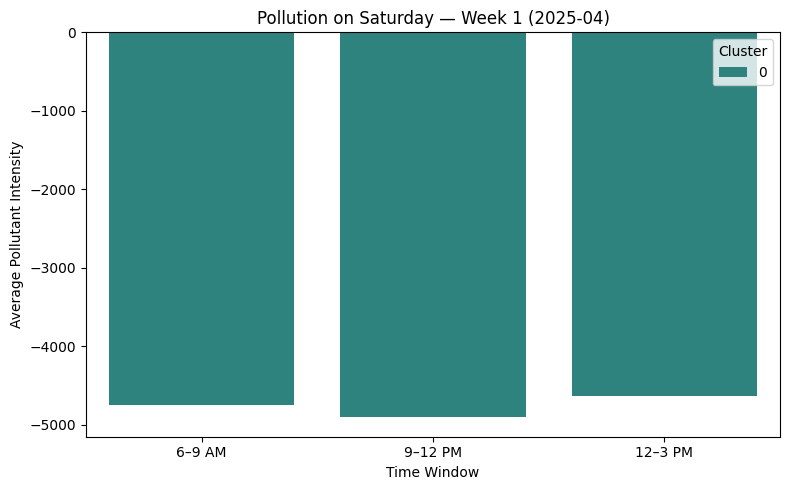

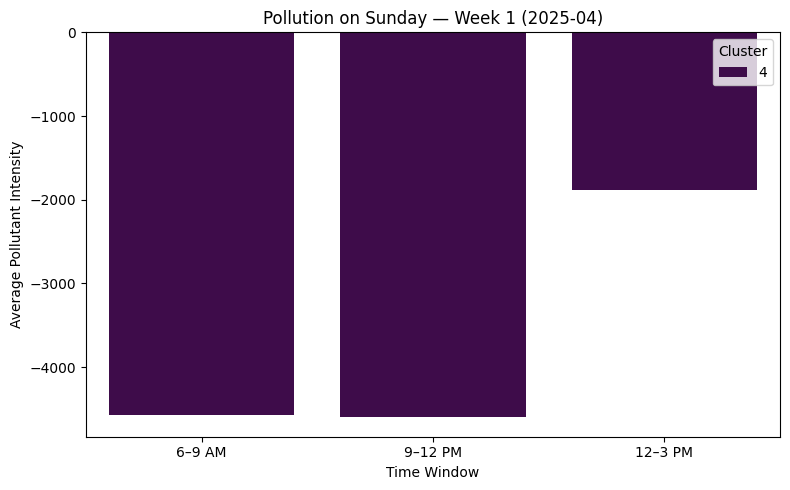

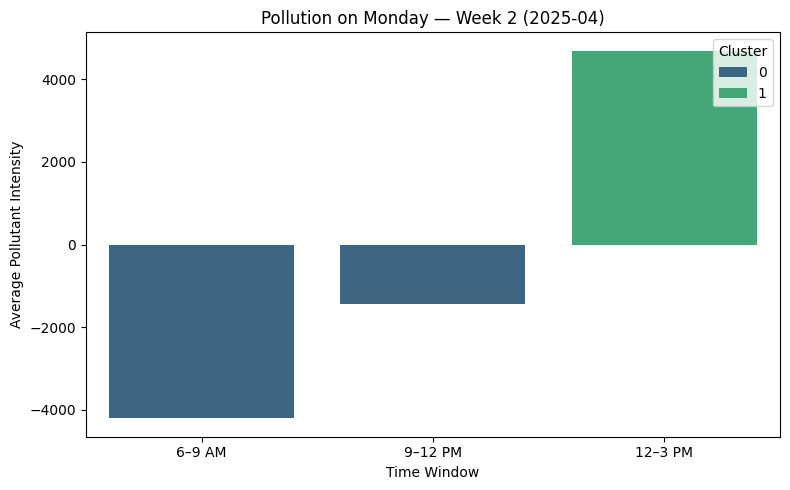

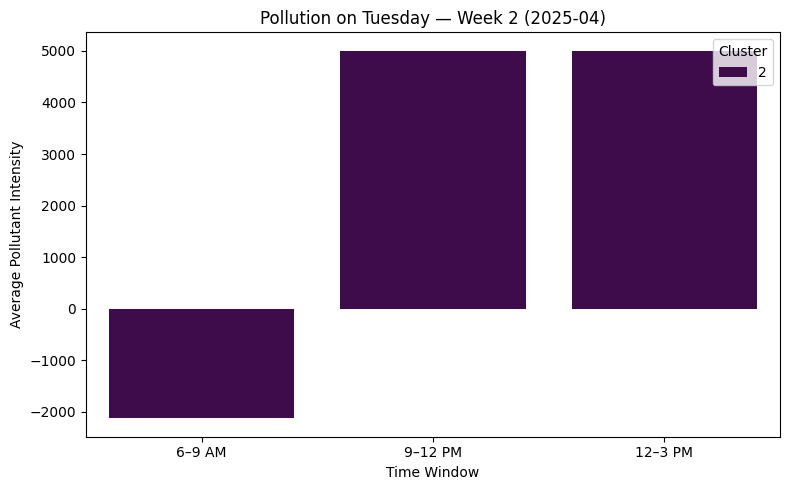

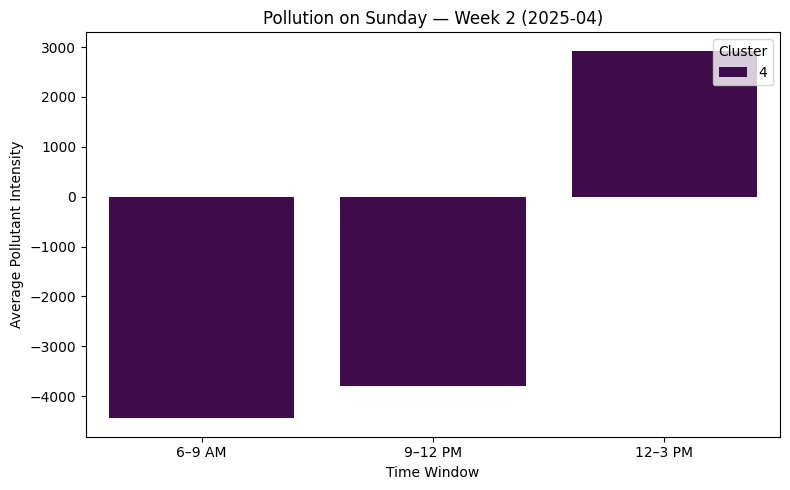

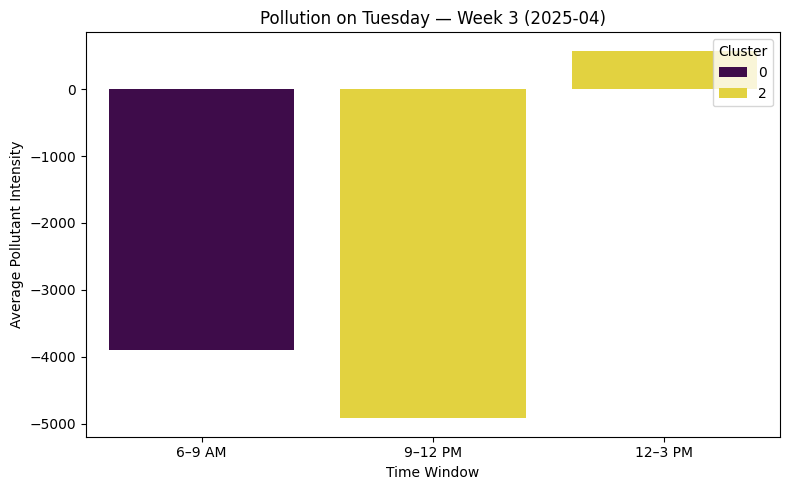

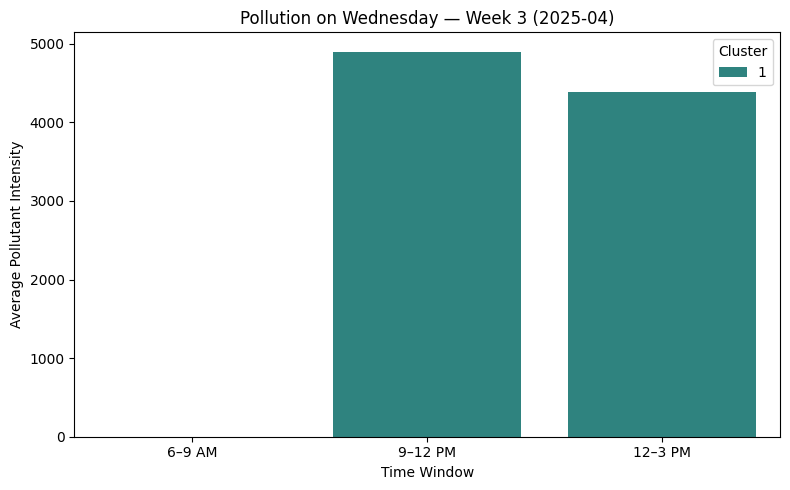

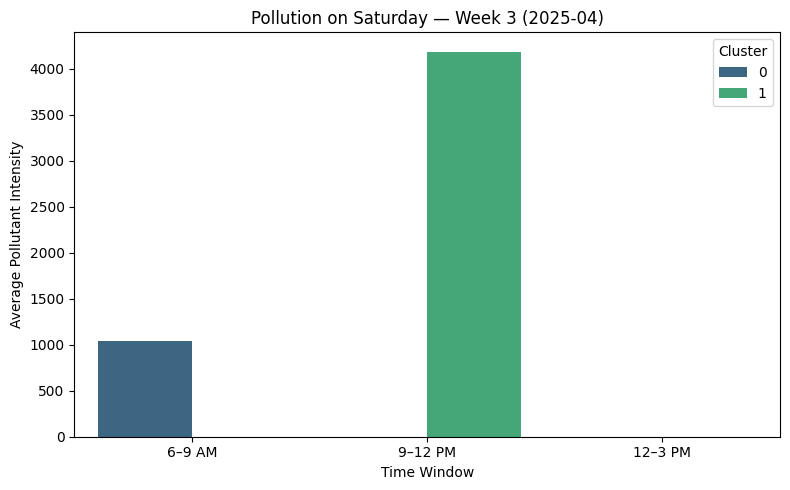

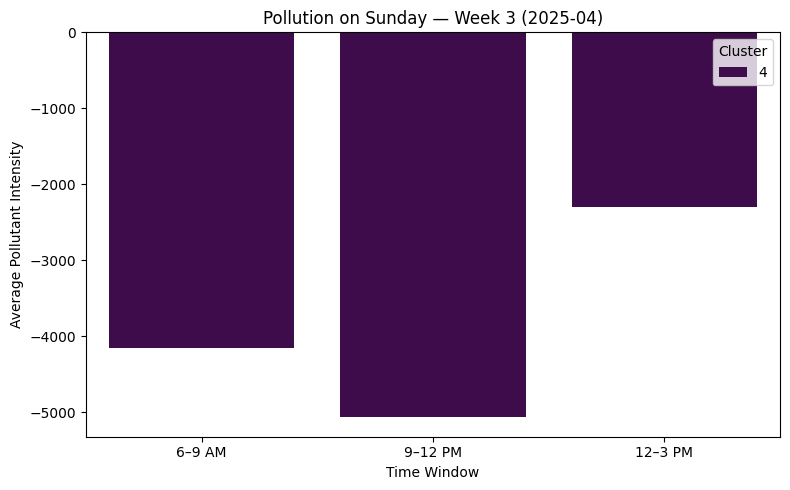

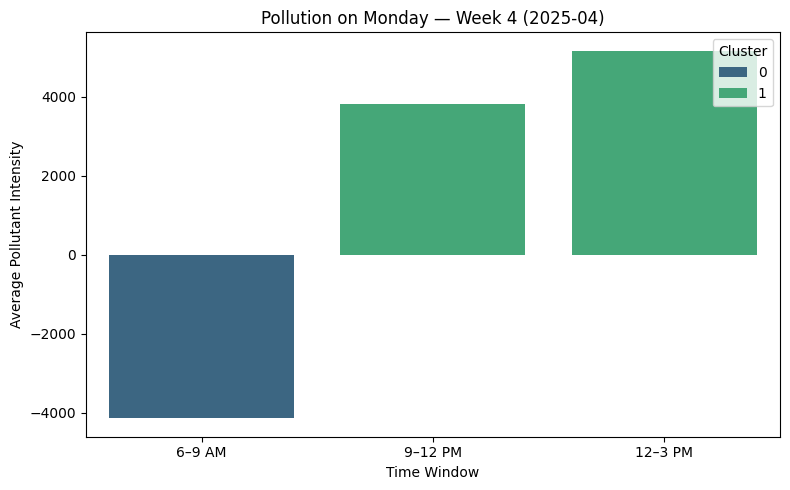

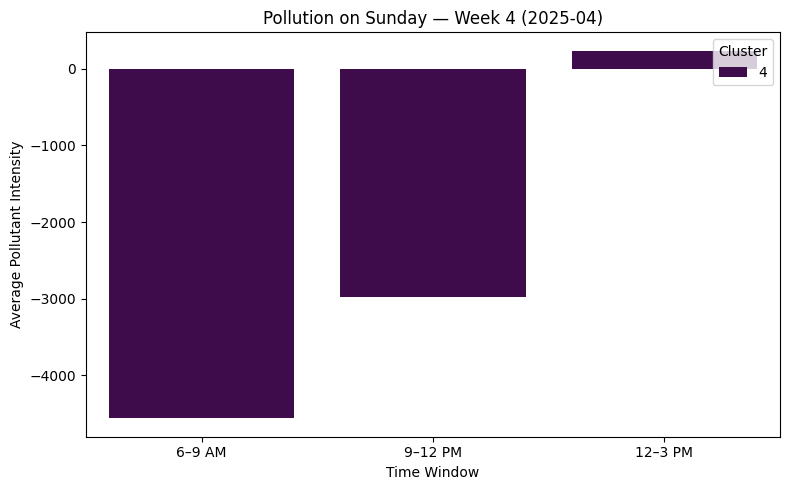

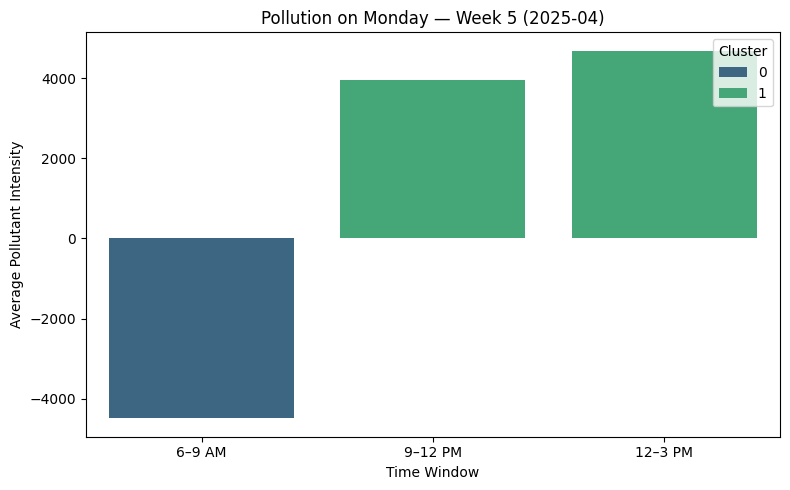

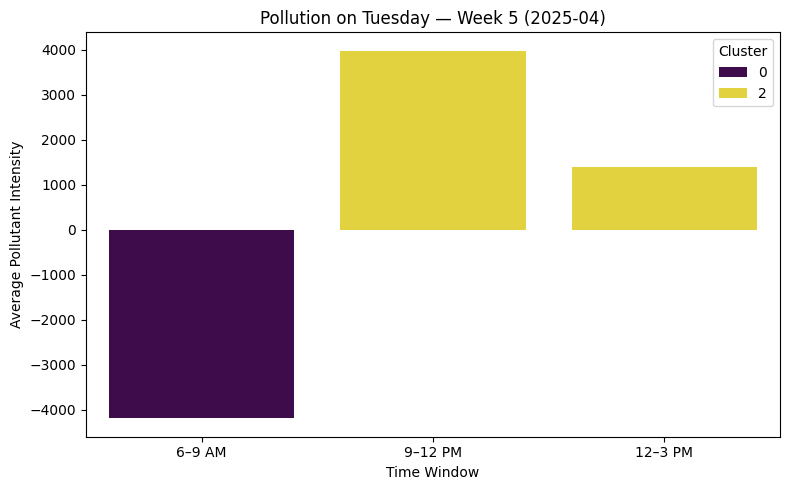


 Month: 2025-05


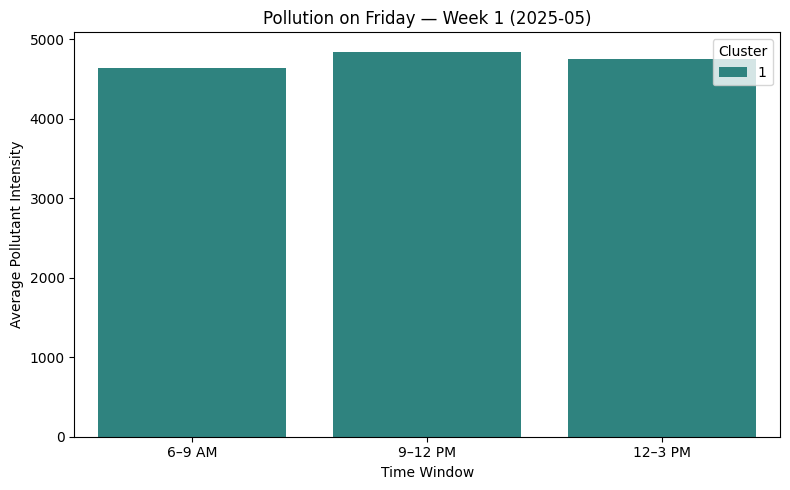

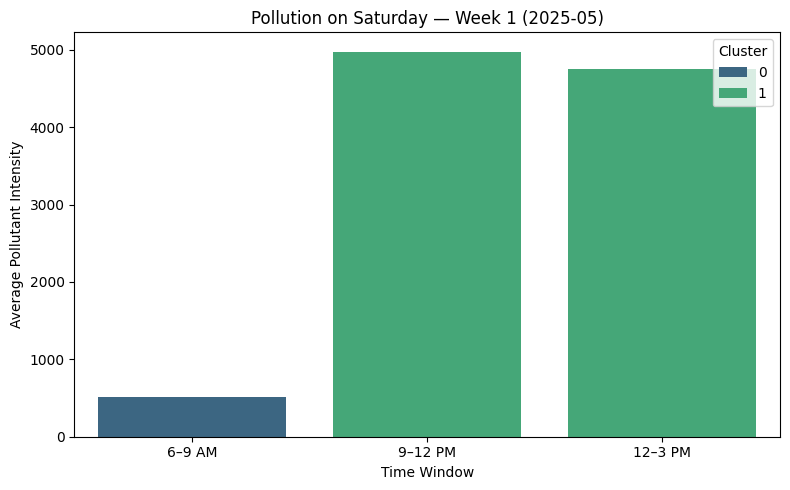

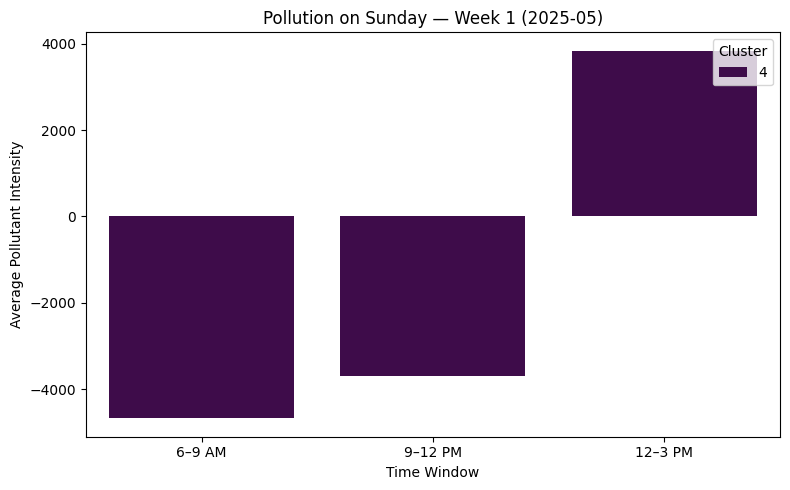

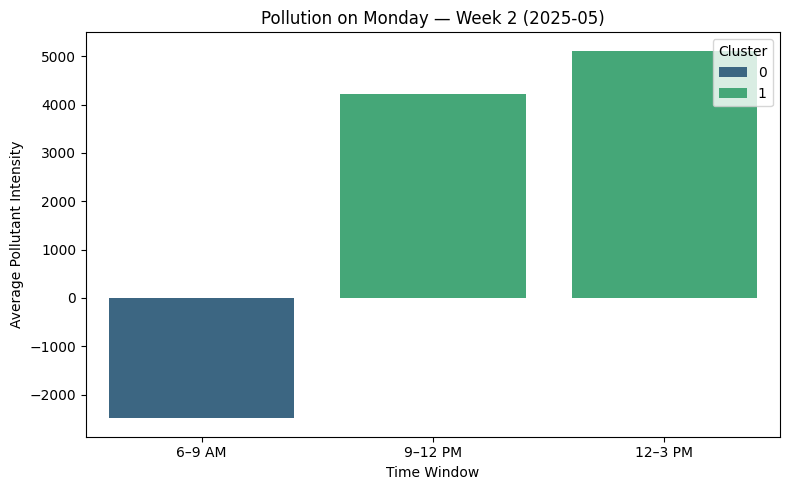

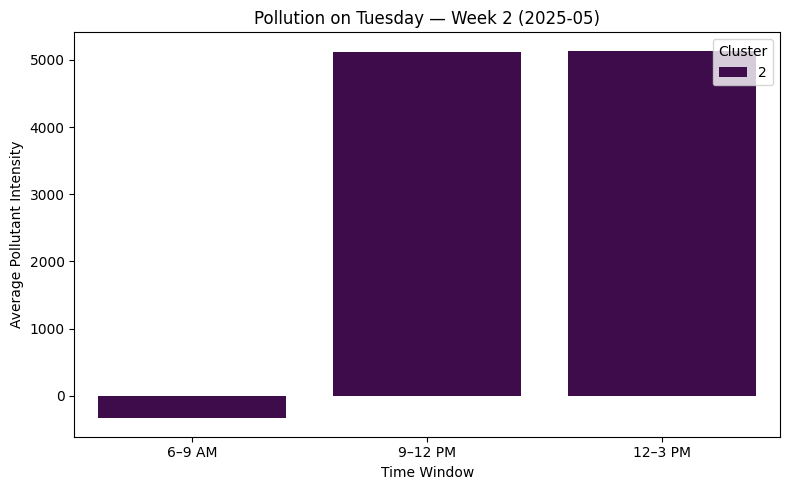

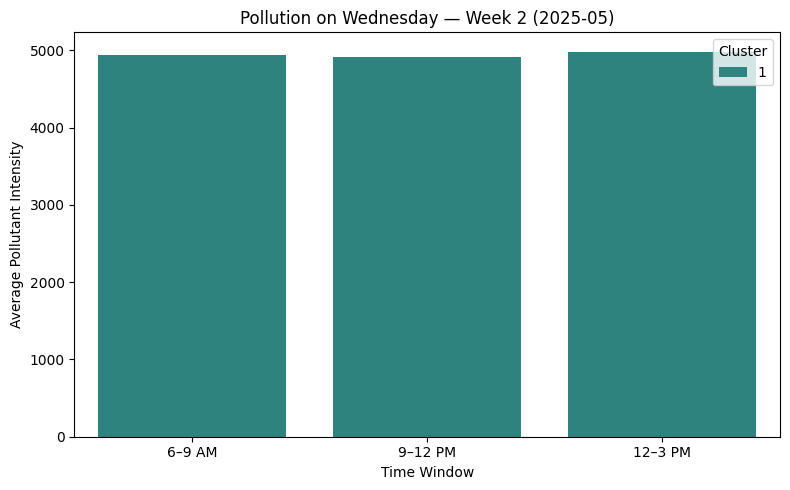

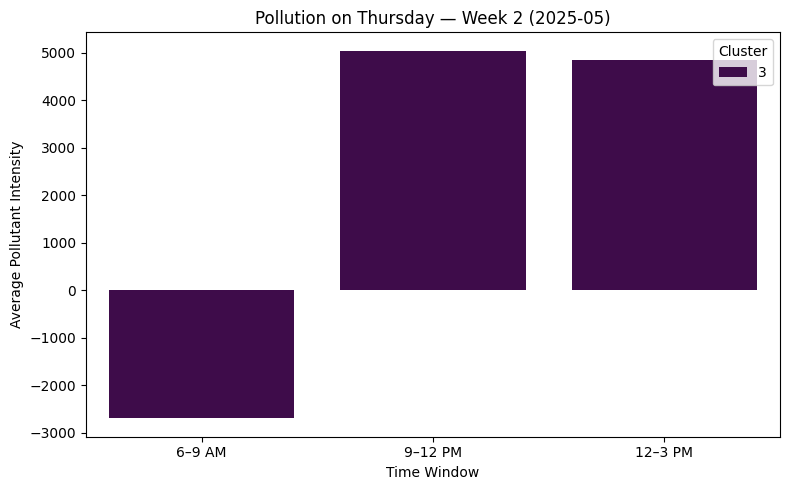

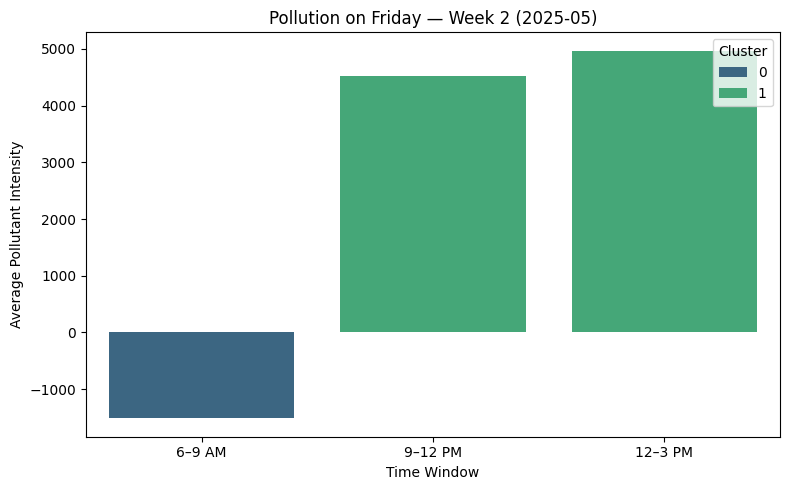

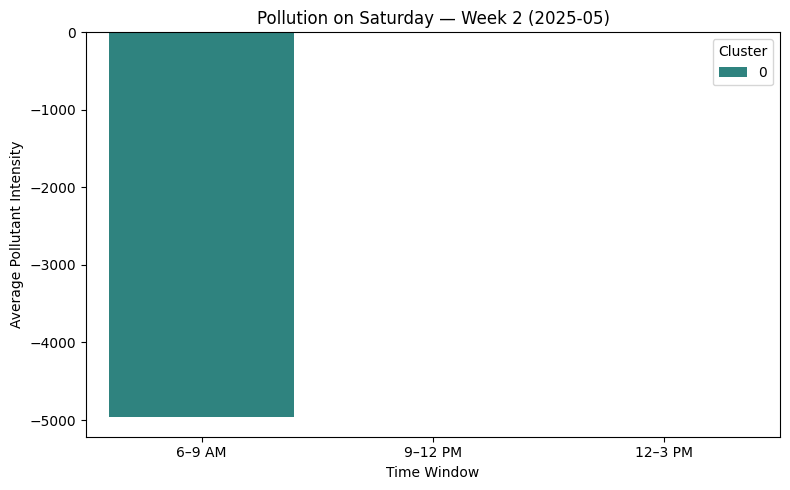

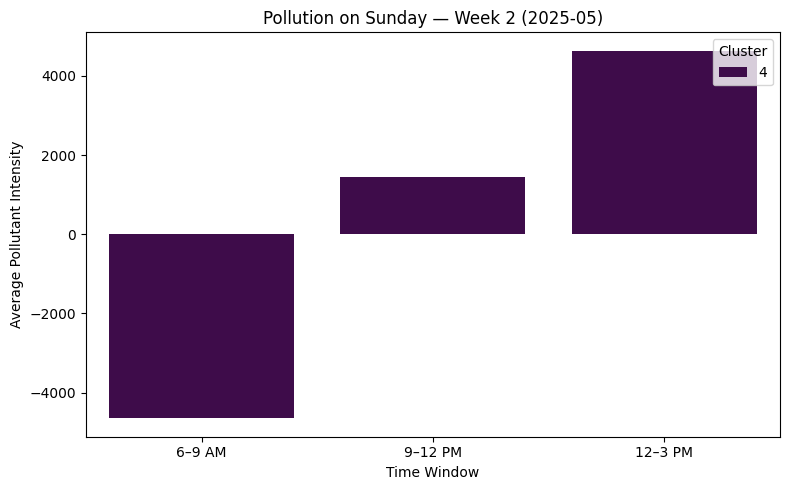

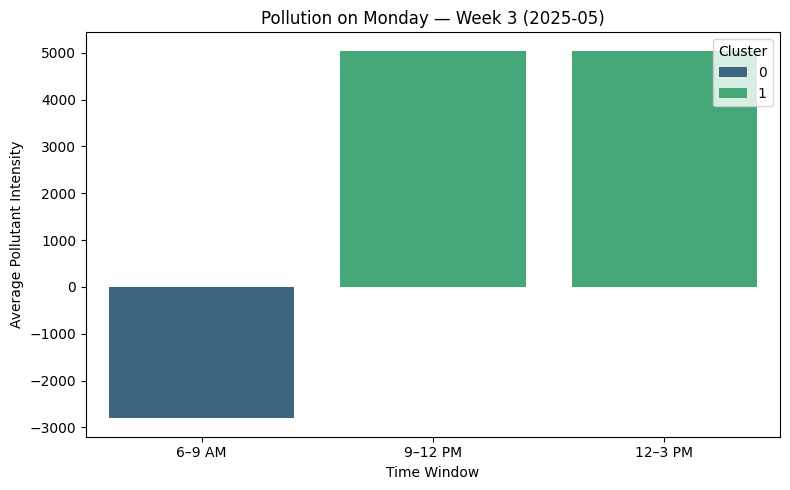

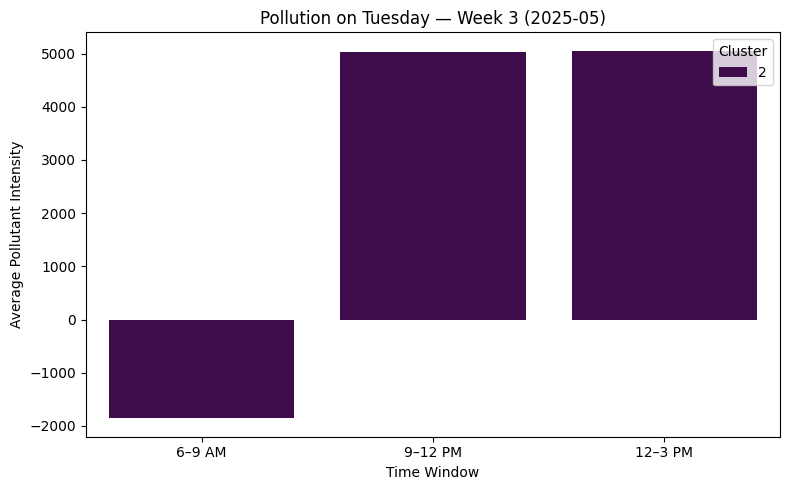

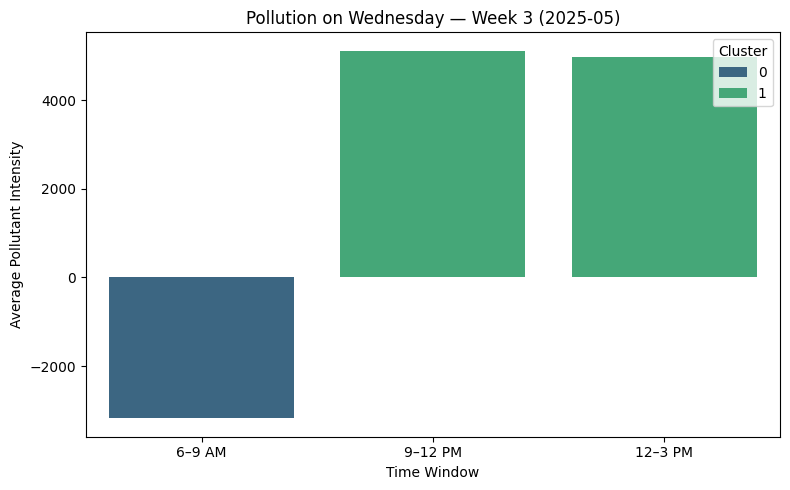

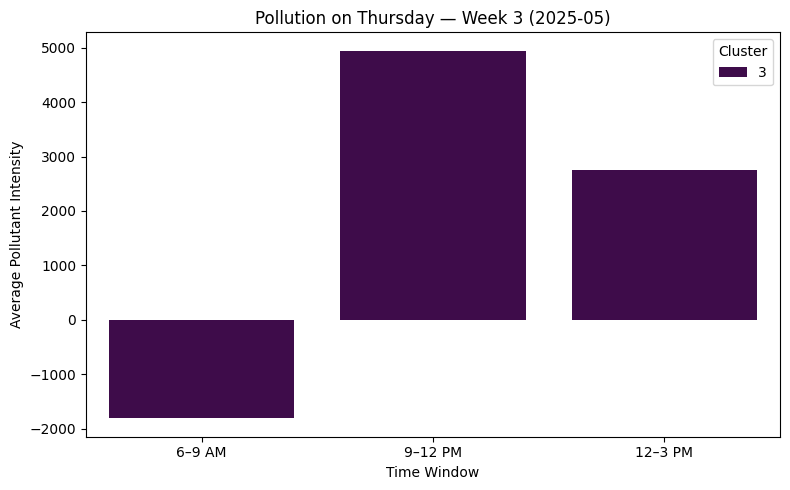

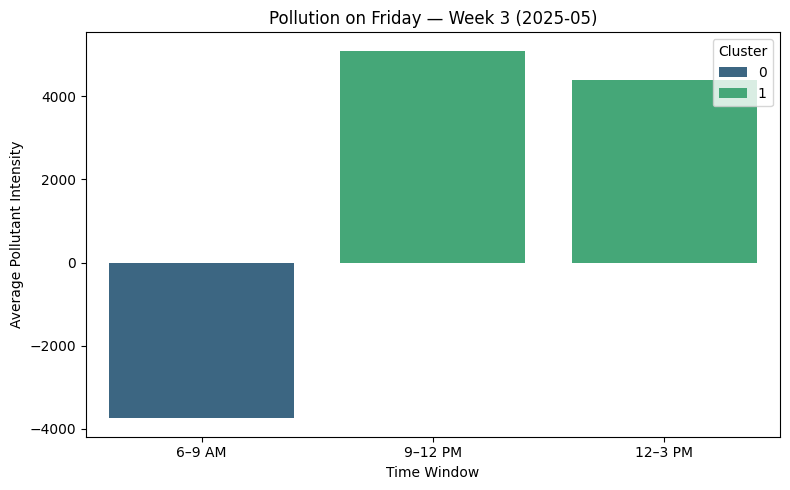

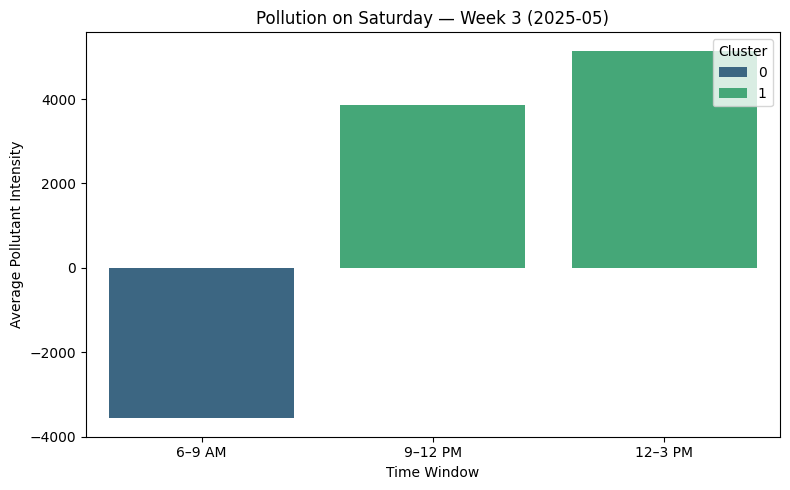

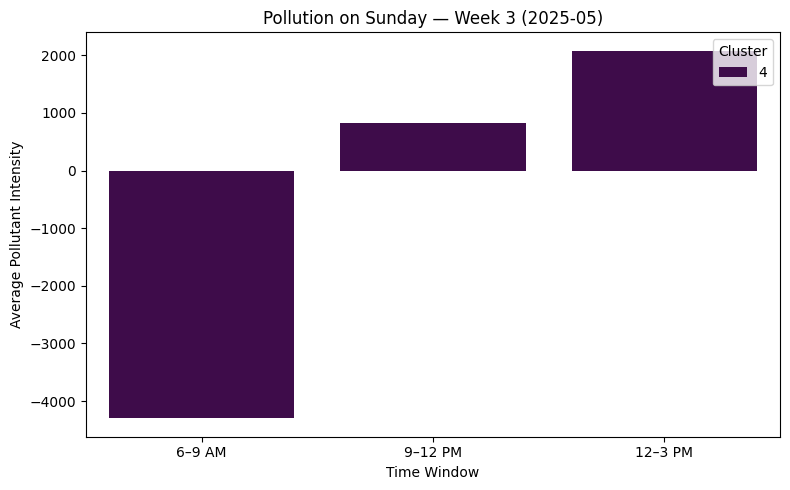

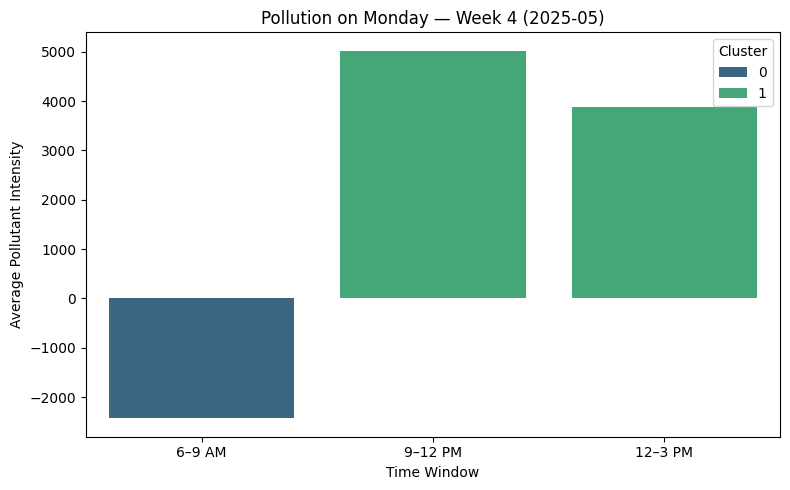

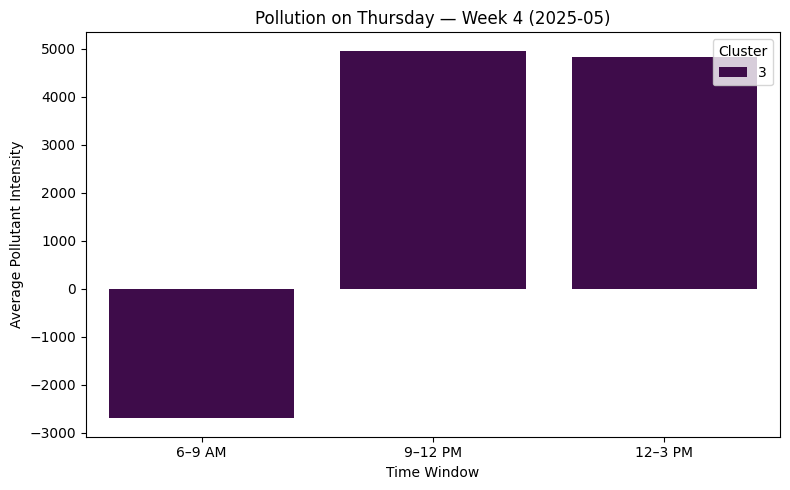

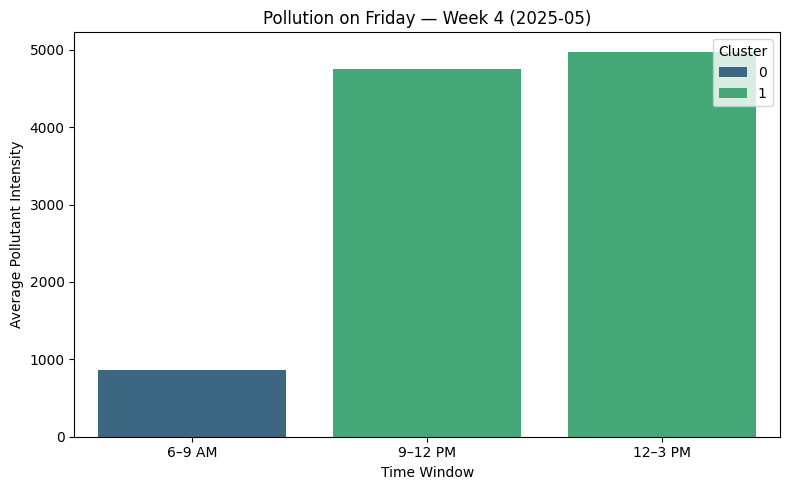

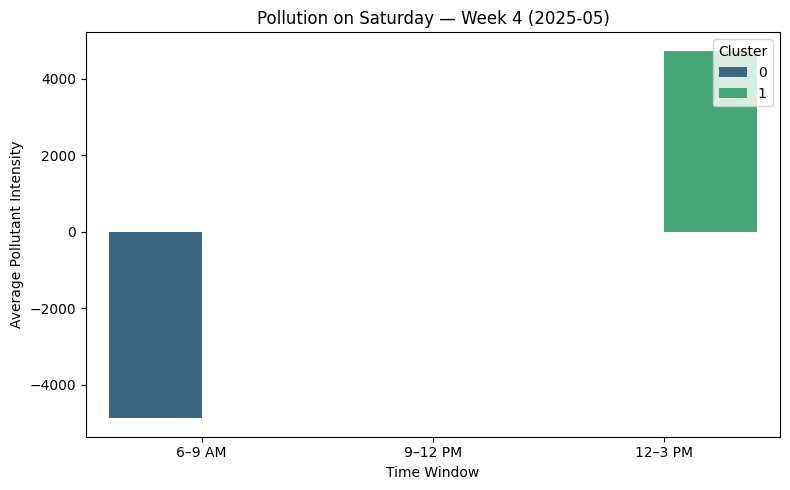

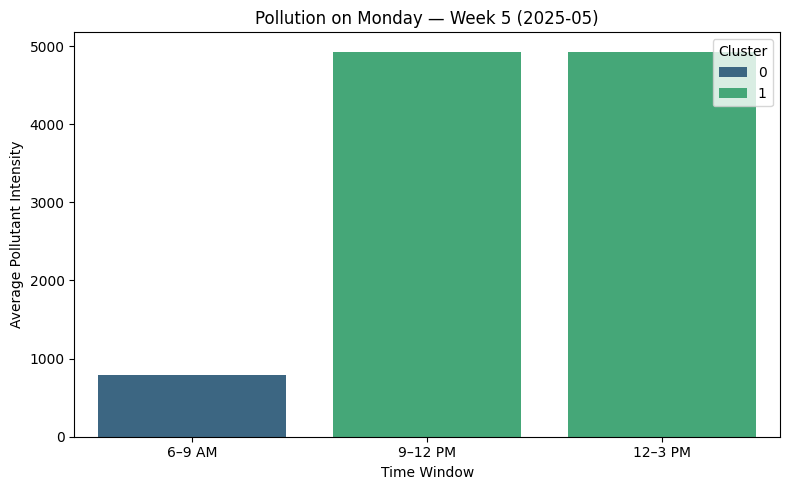

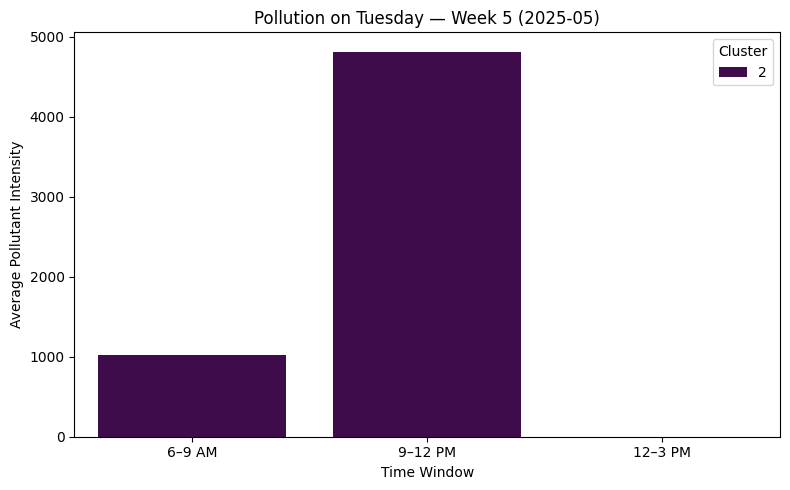

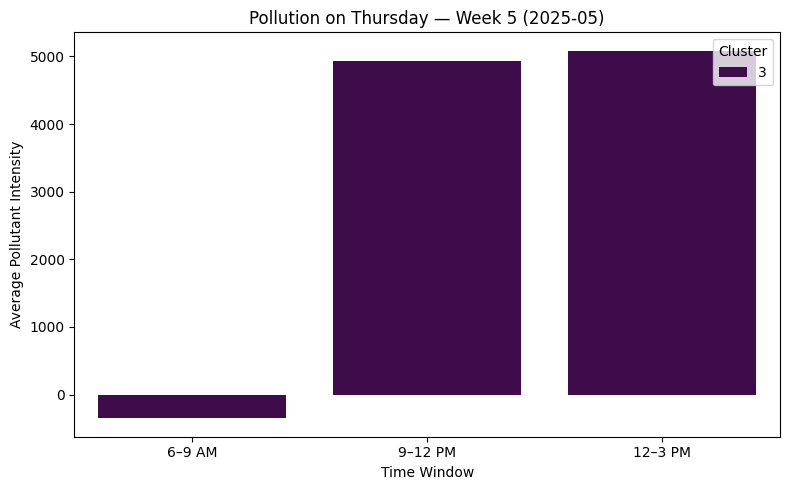

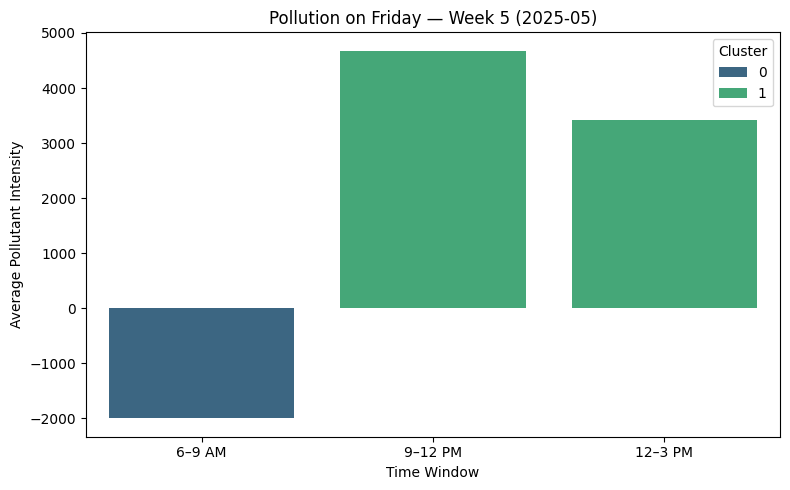

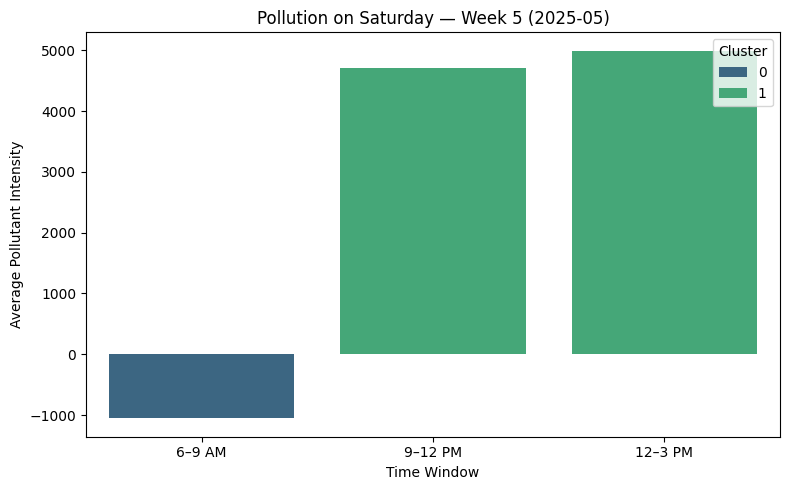


 Month: 2025-06


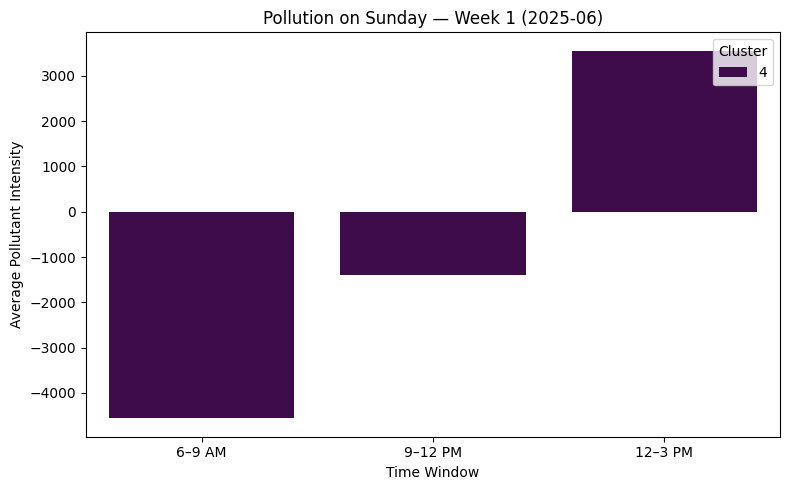

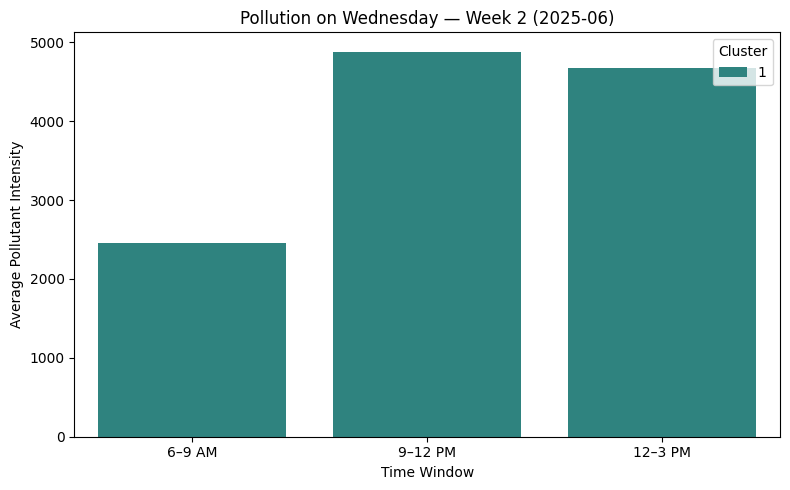

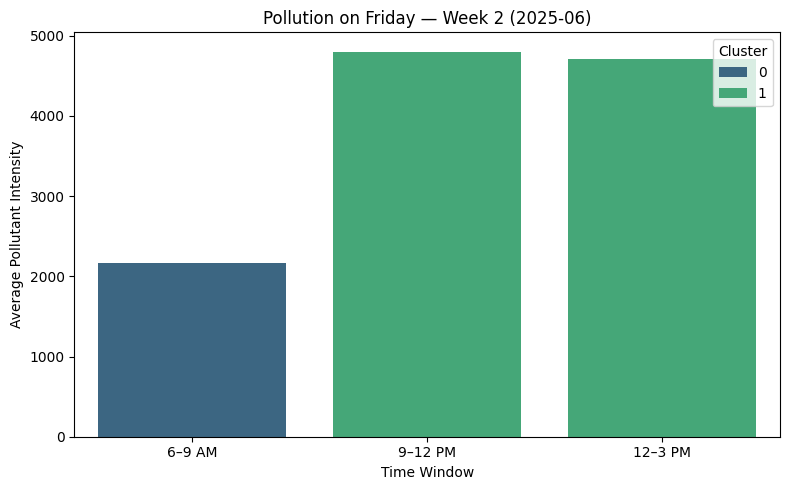

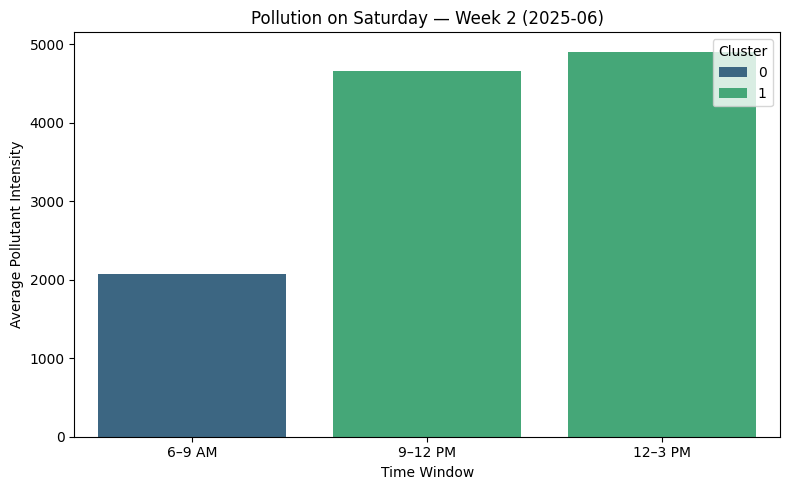

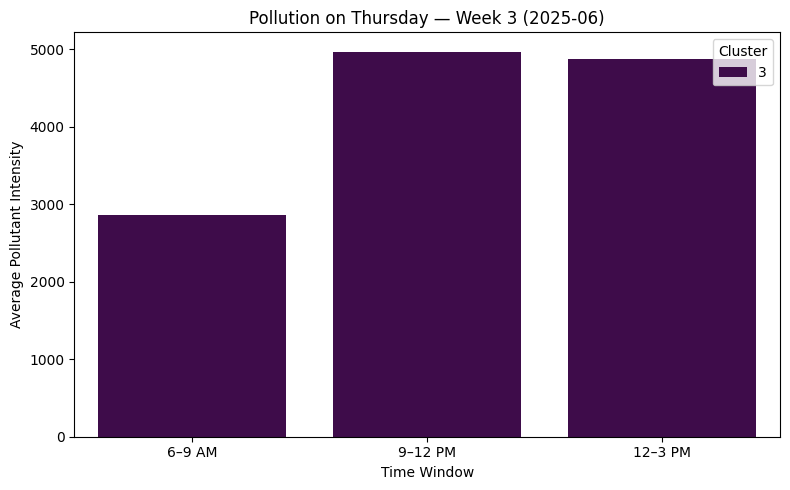

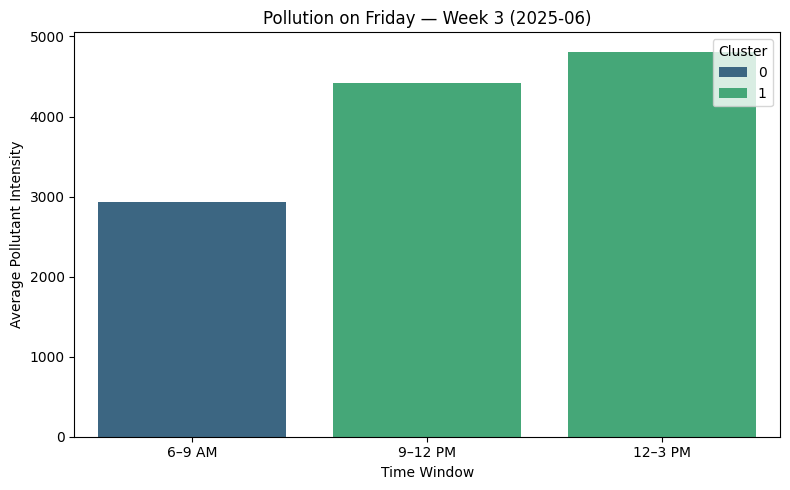

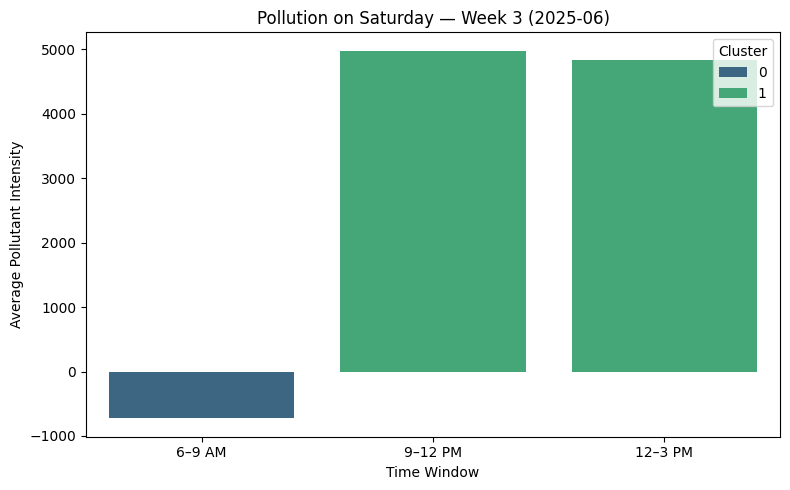

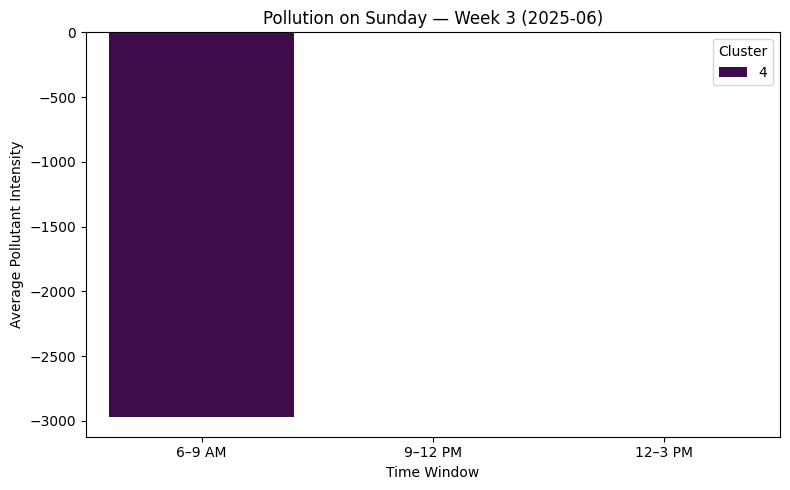

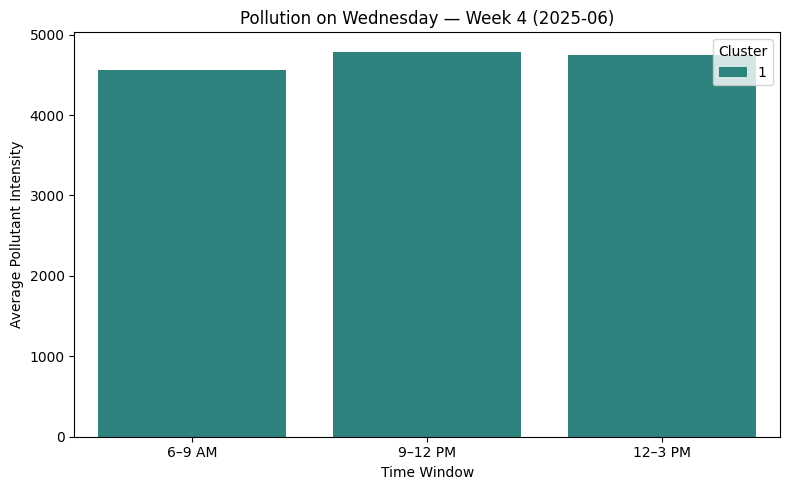

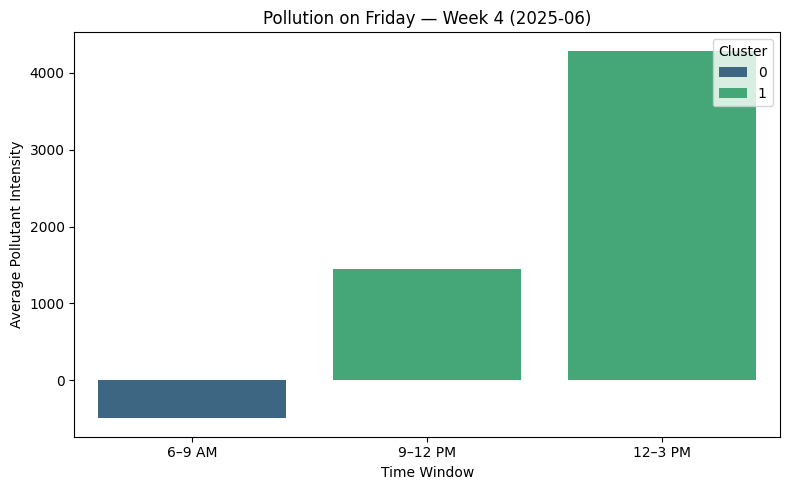

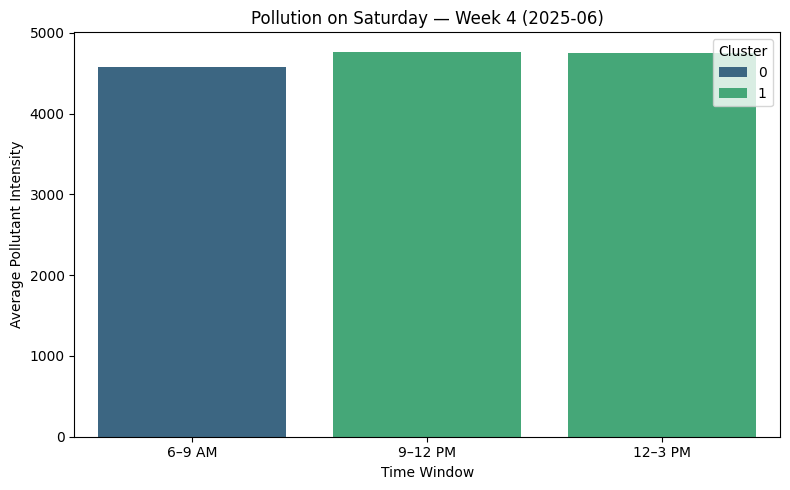

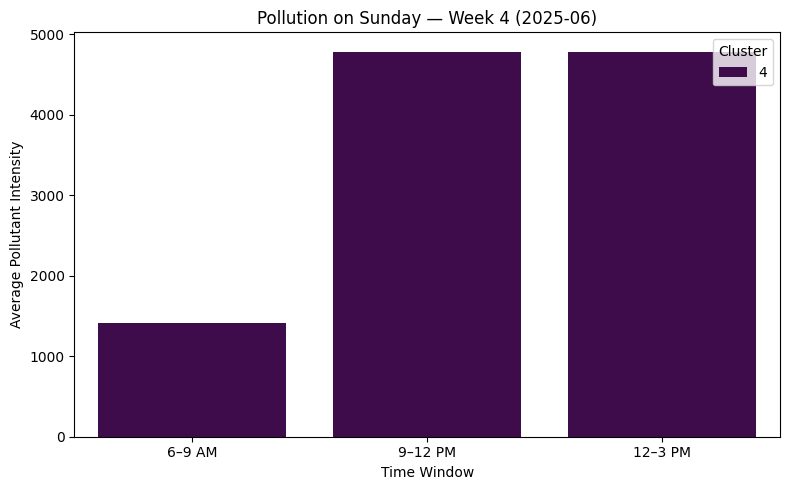

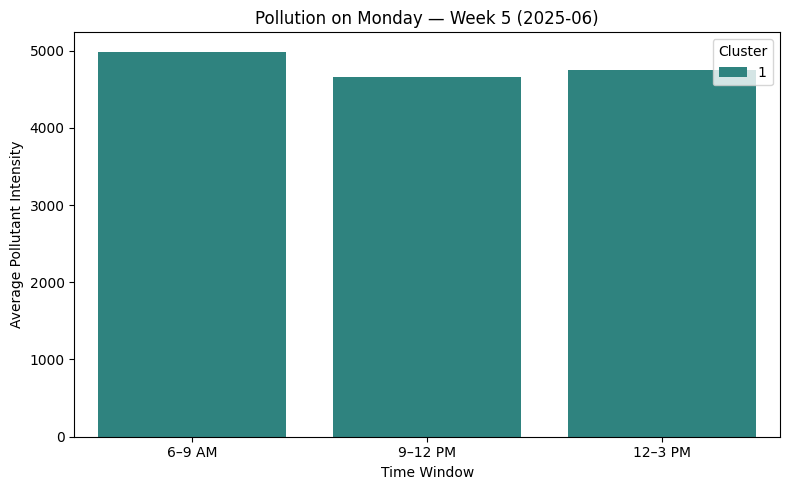

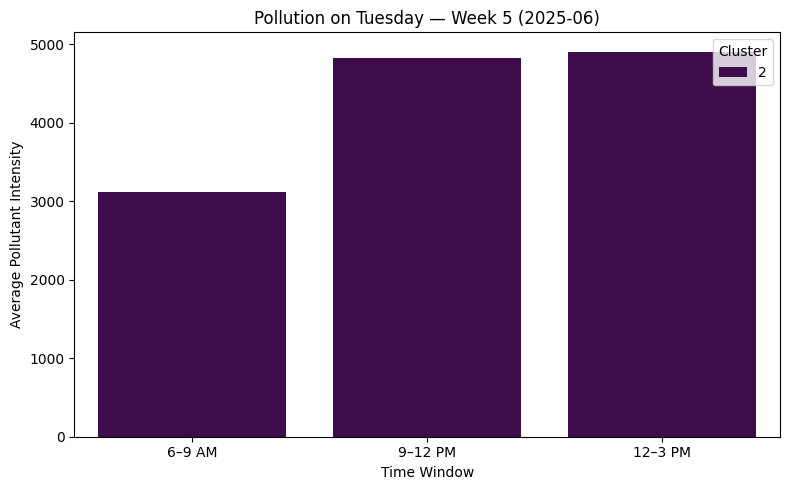

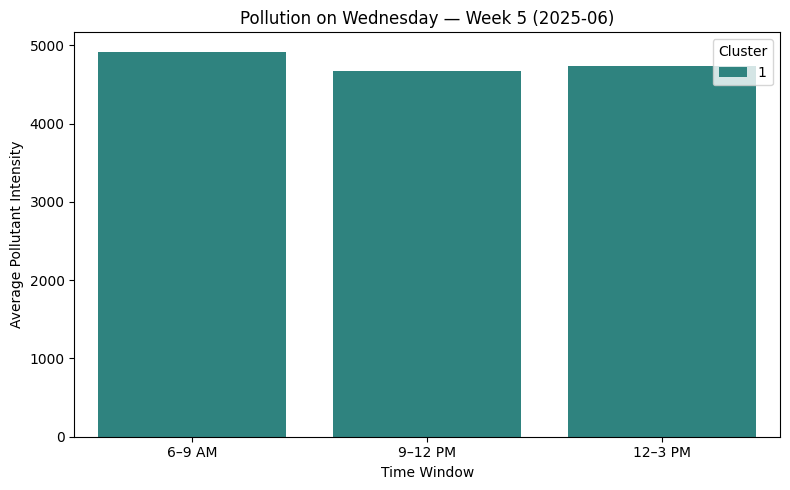

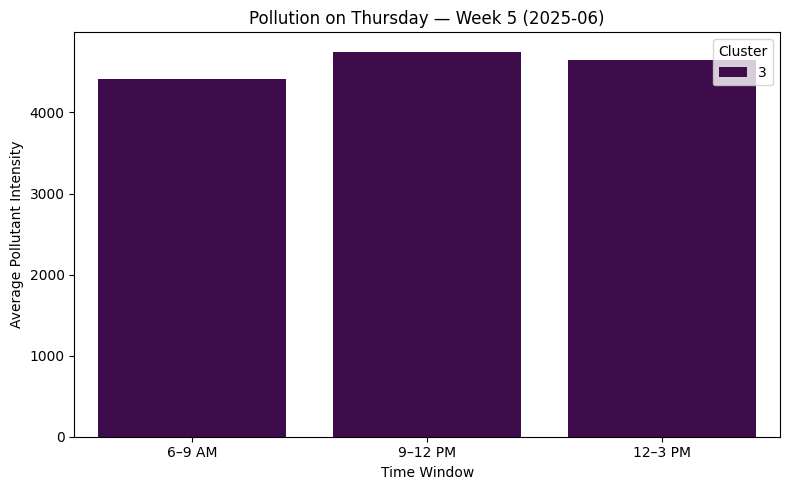

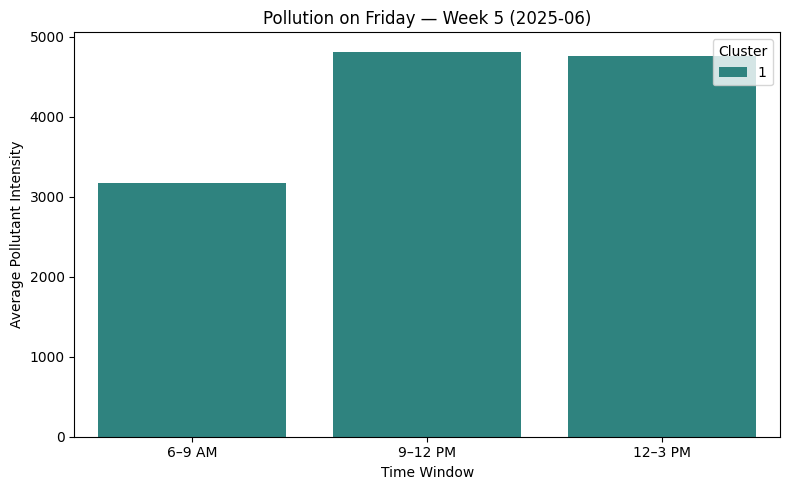

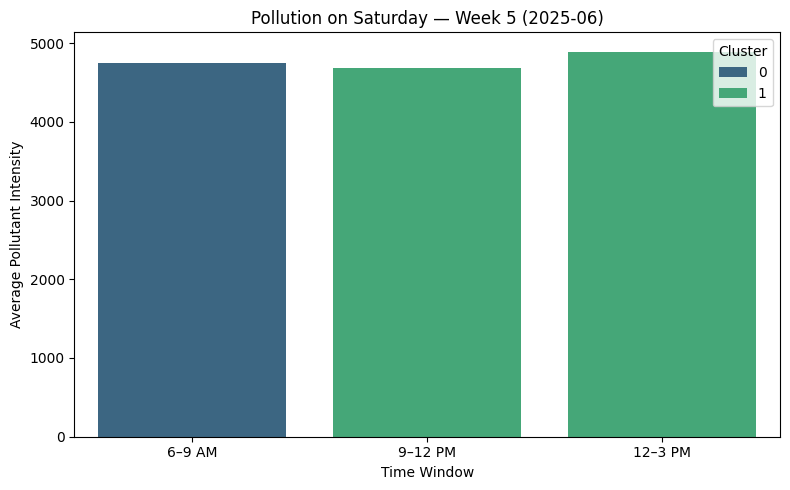

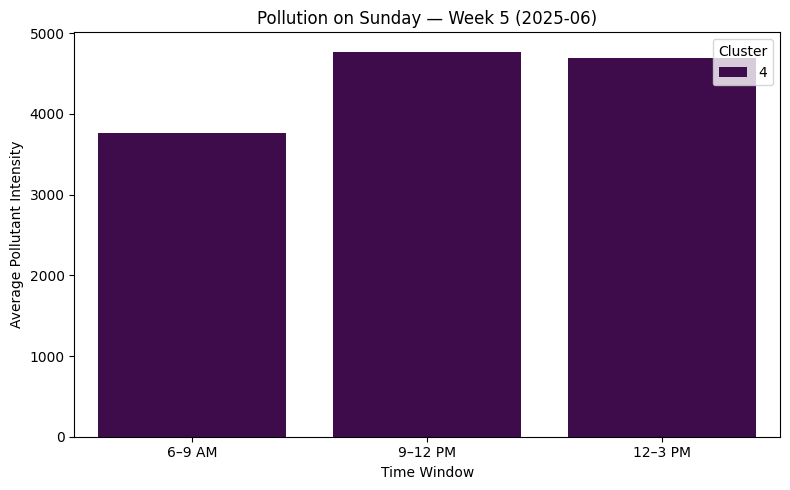

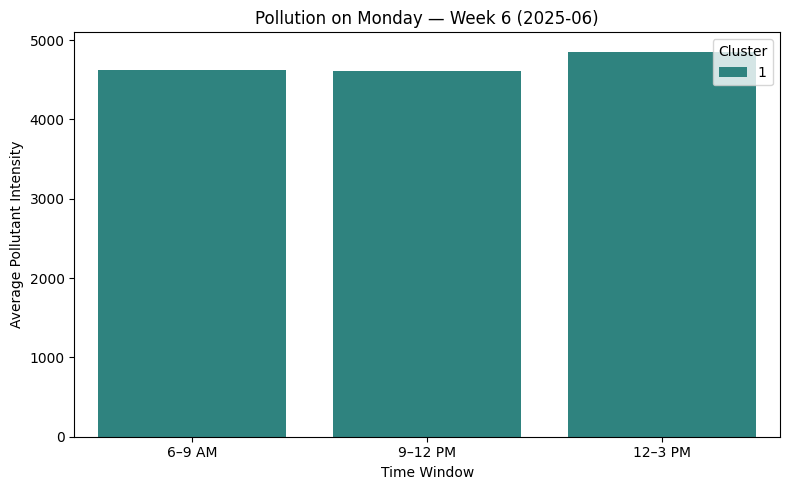


 Month: 2025-07


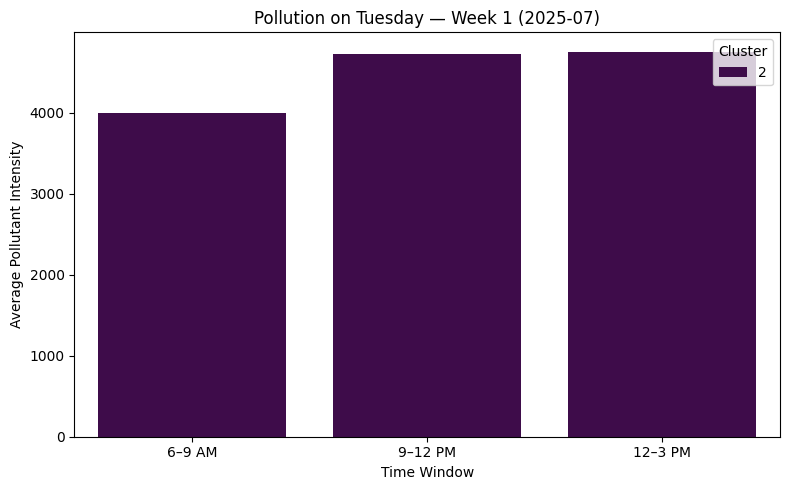

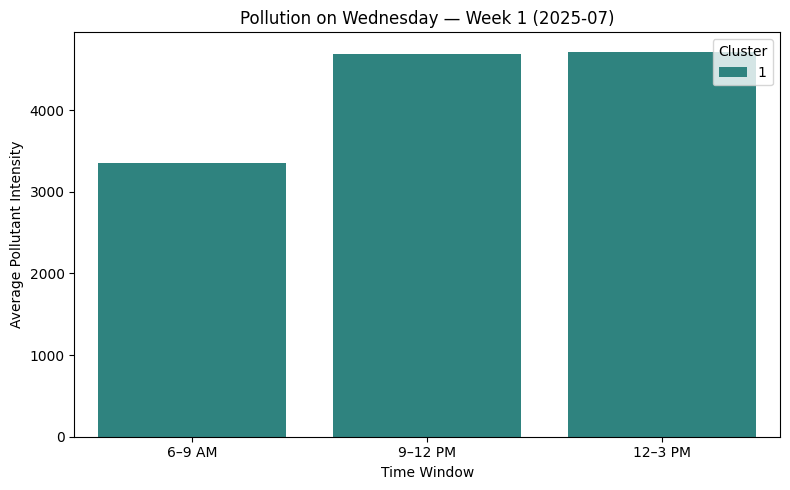

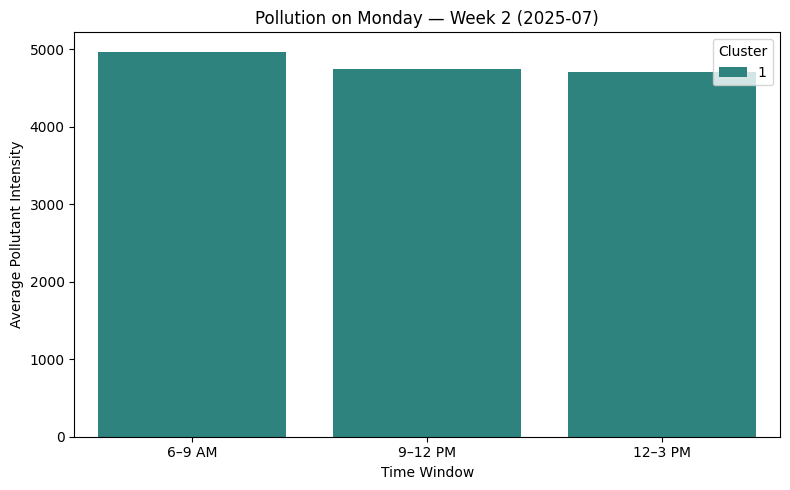

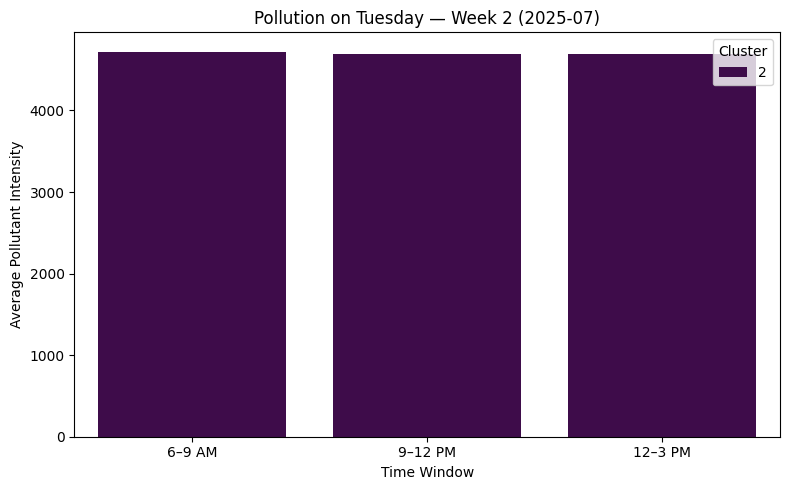

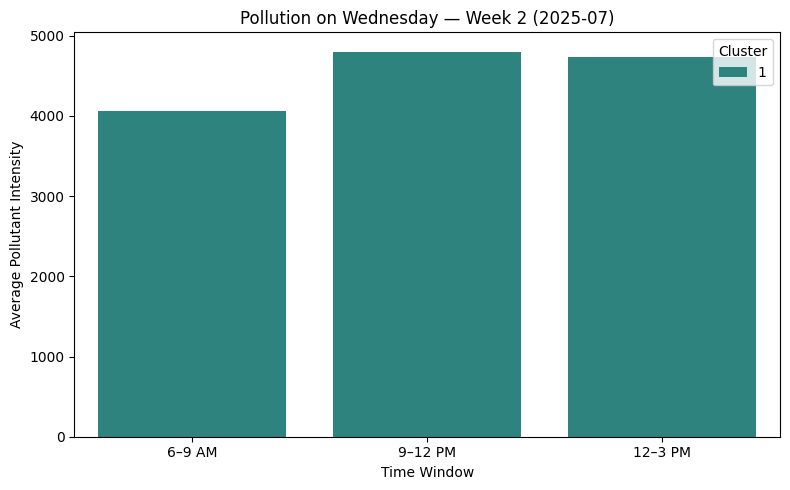

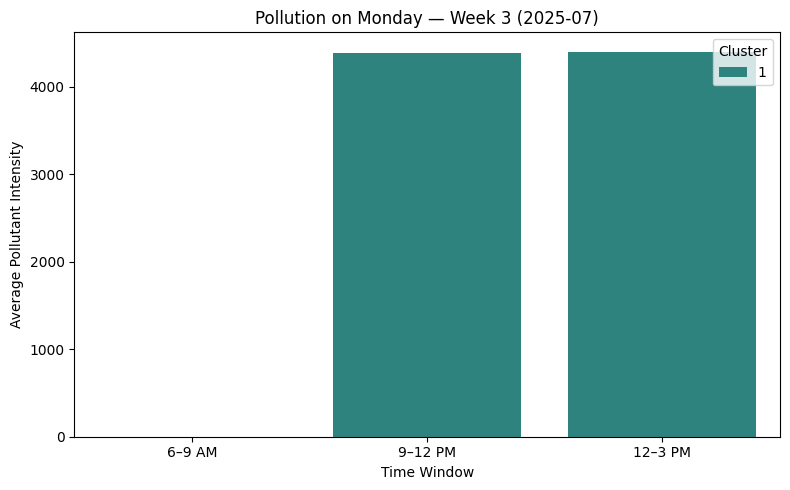

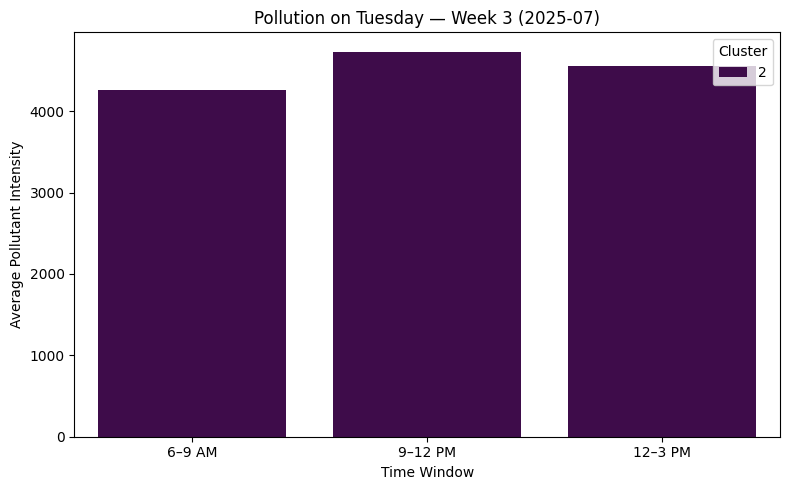

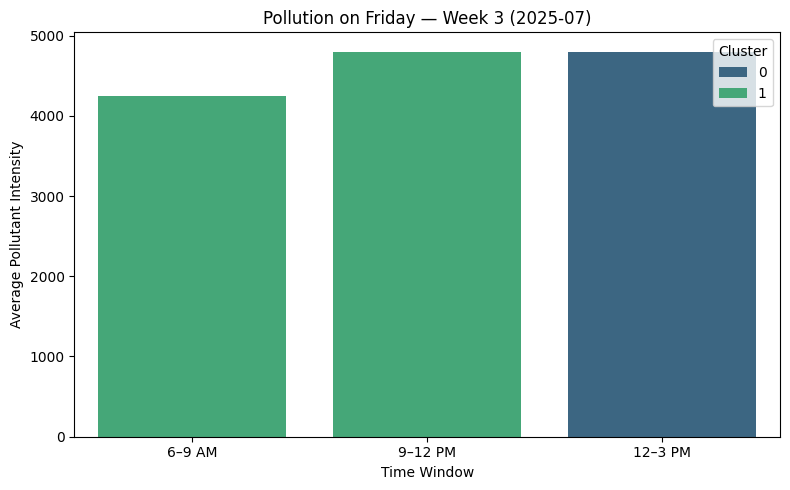

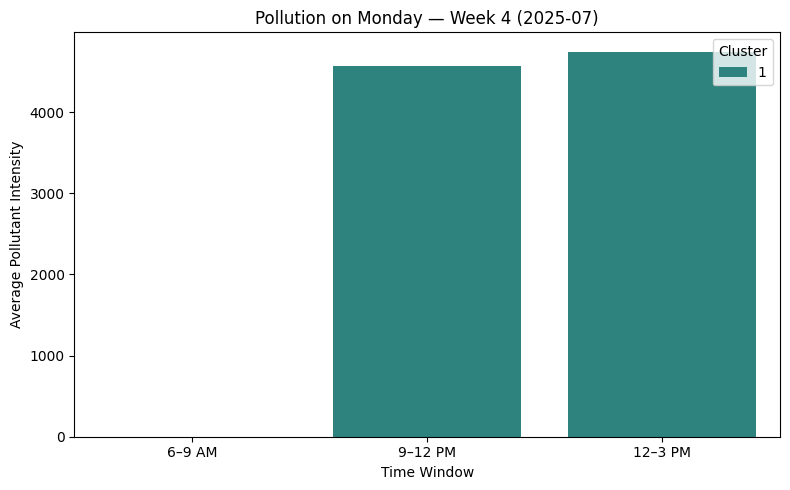

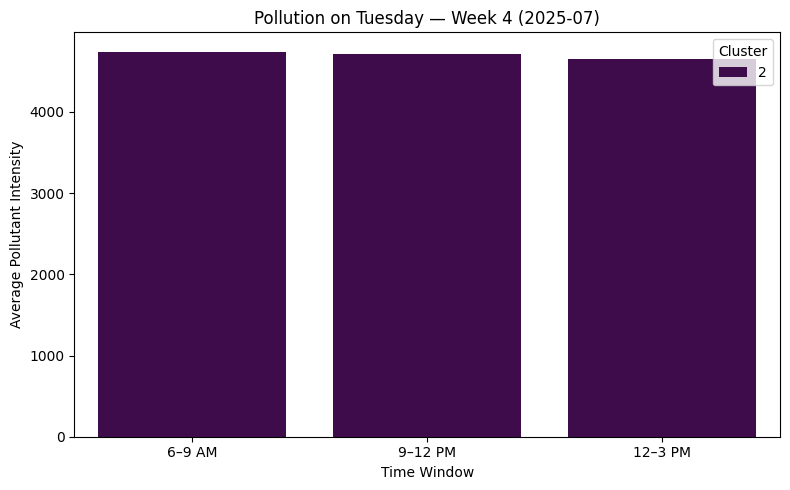

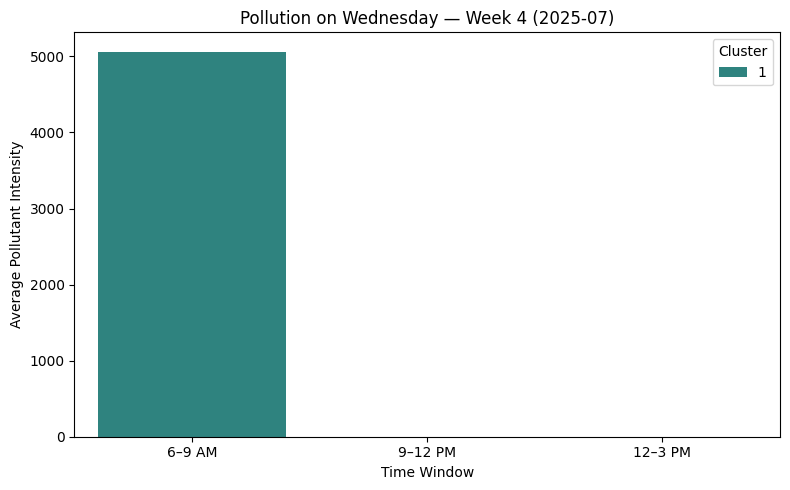

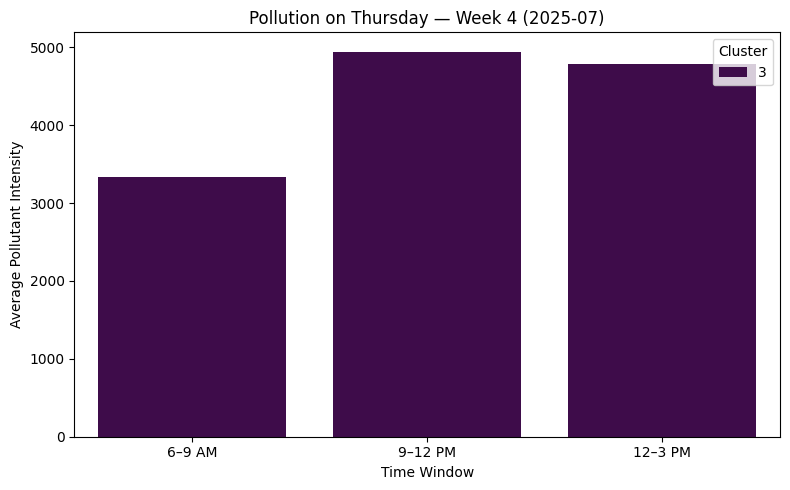

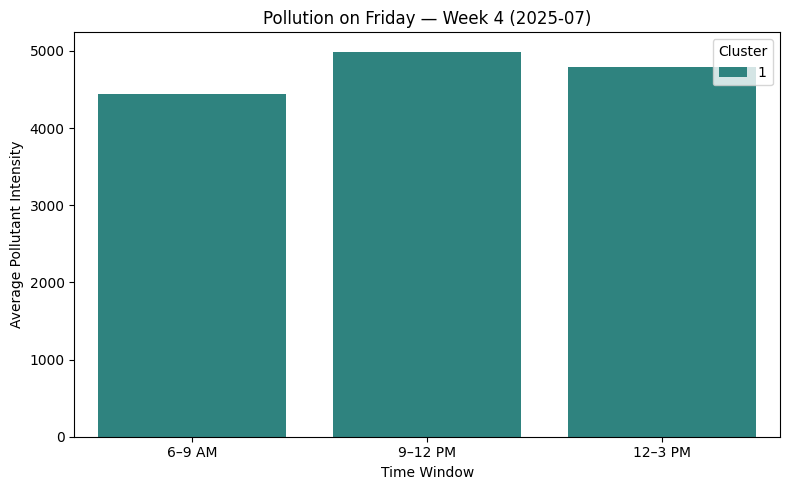

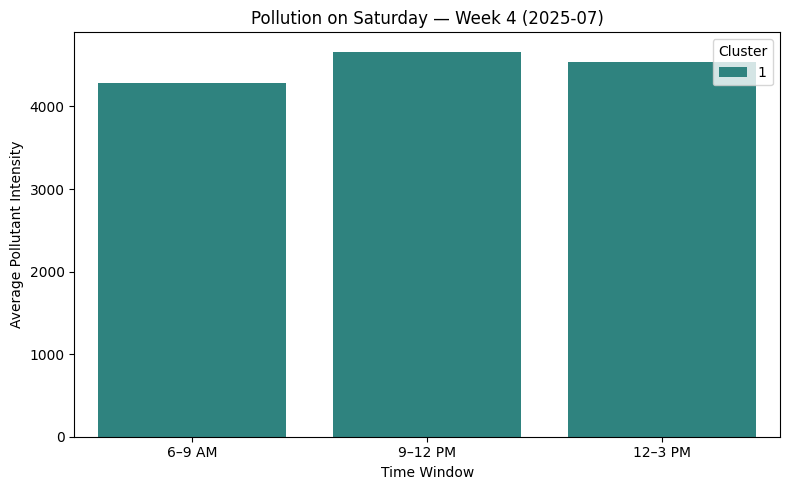

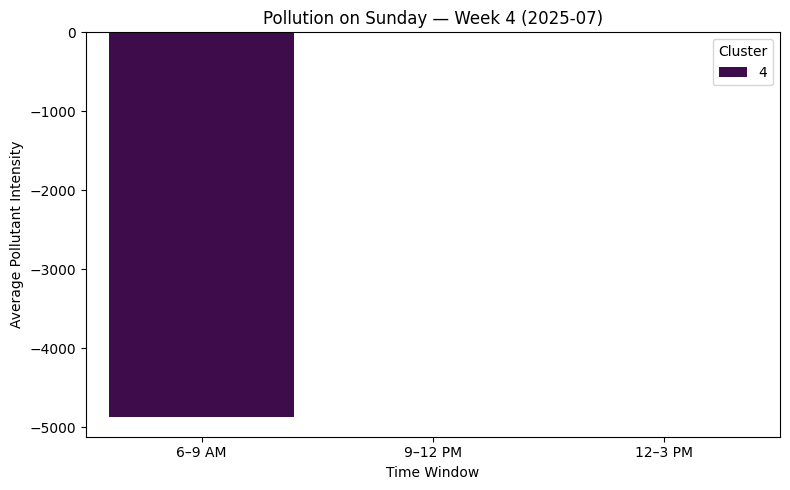

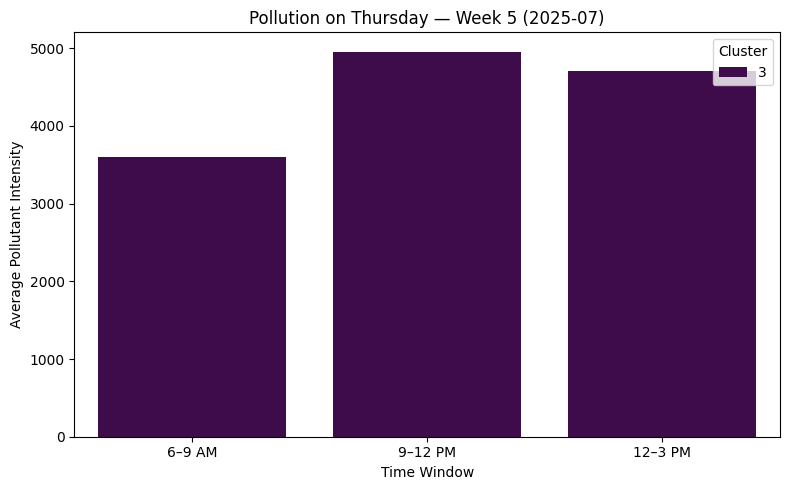


 Month: 2025-08


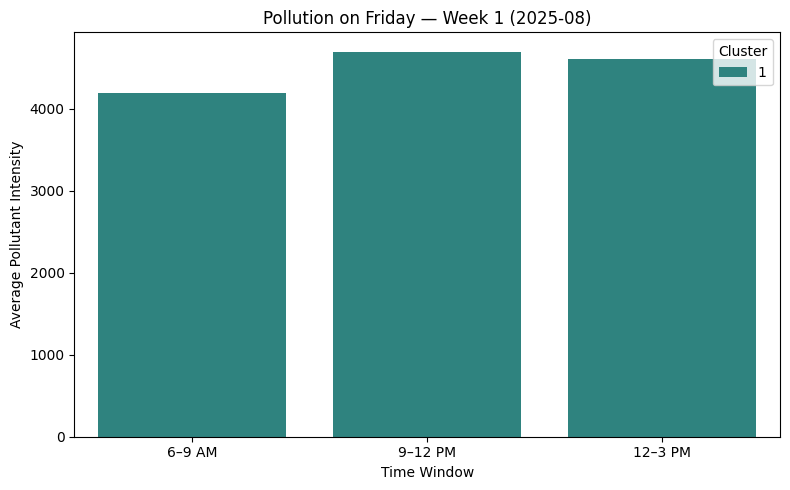

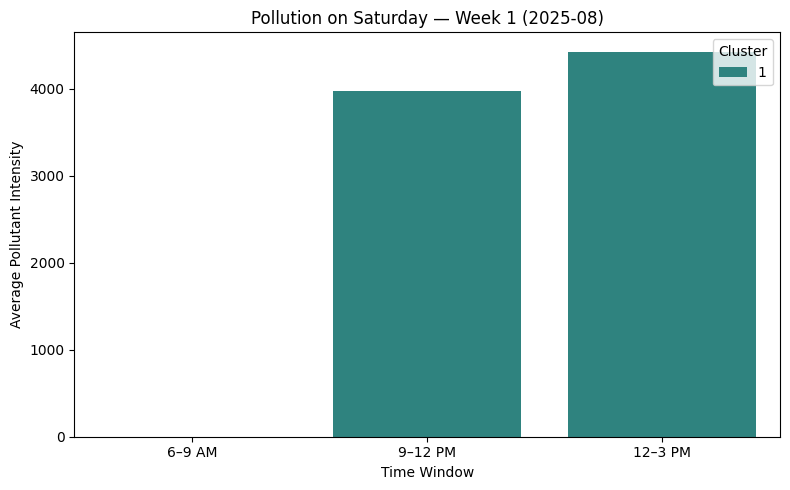

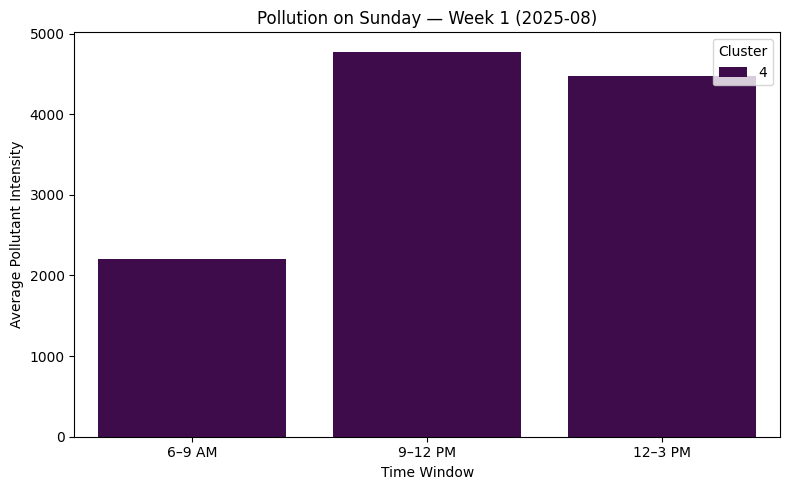

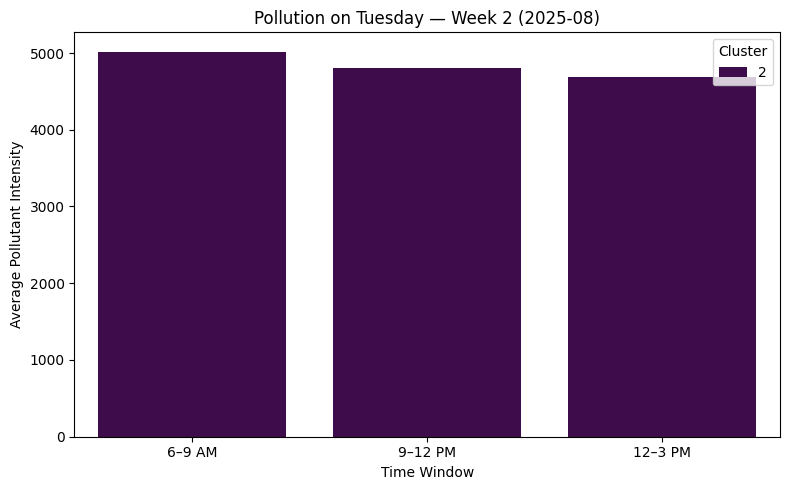

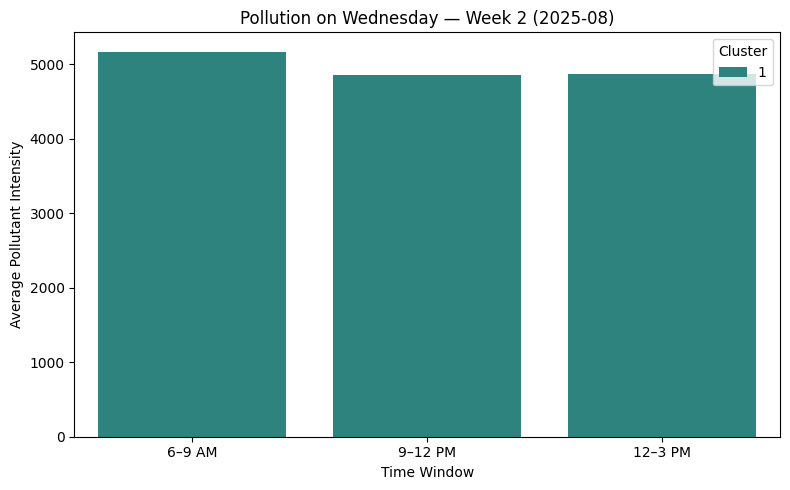

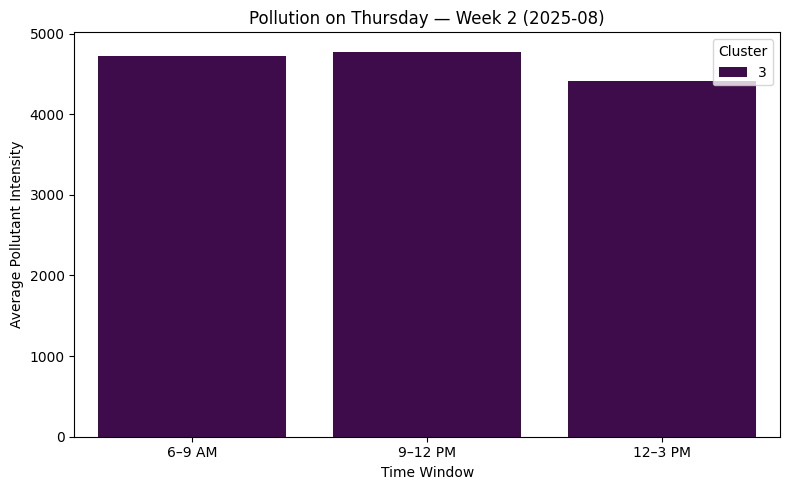

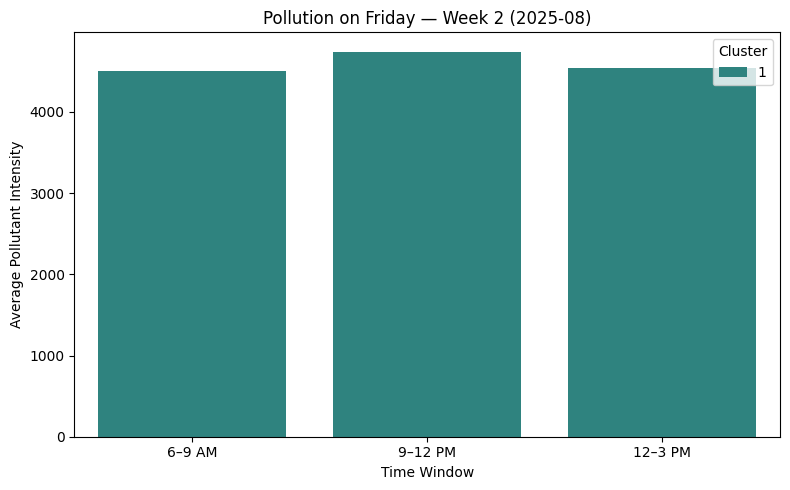

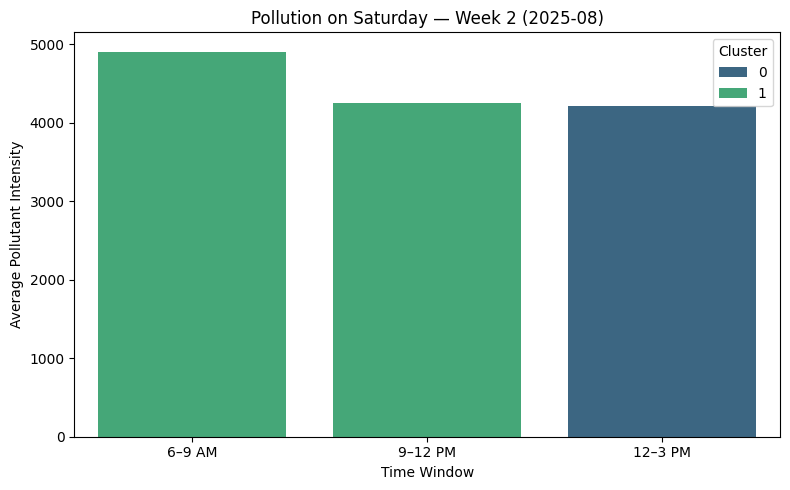

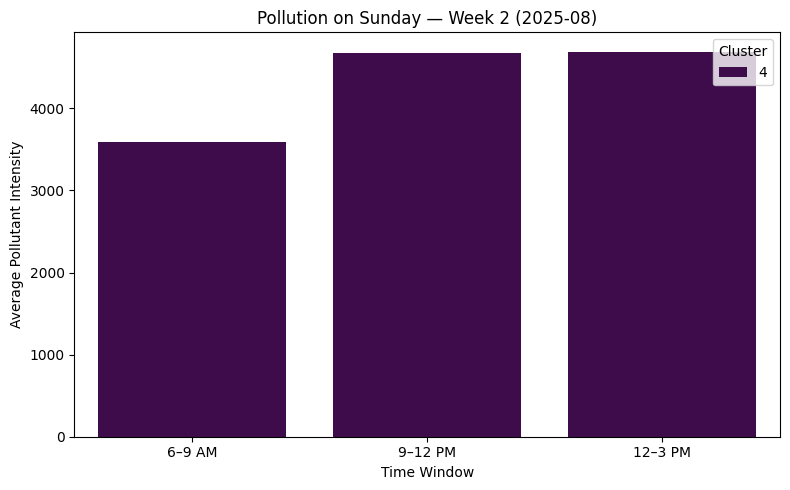

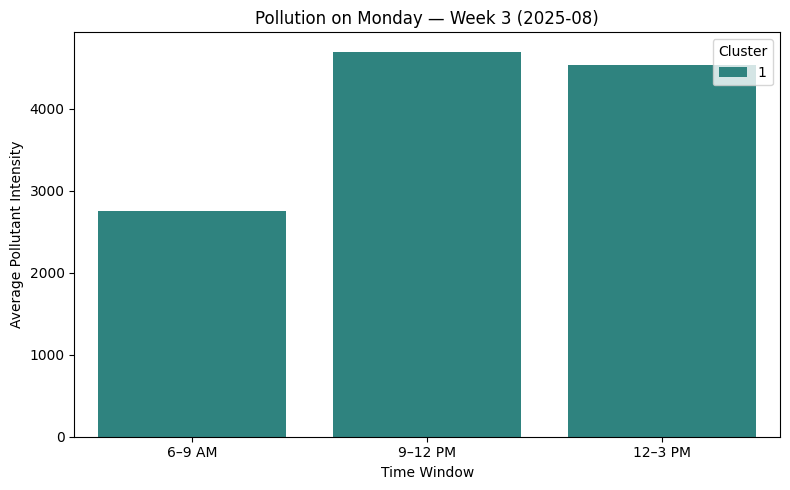

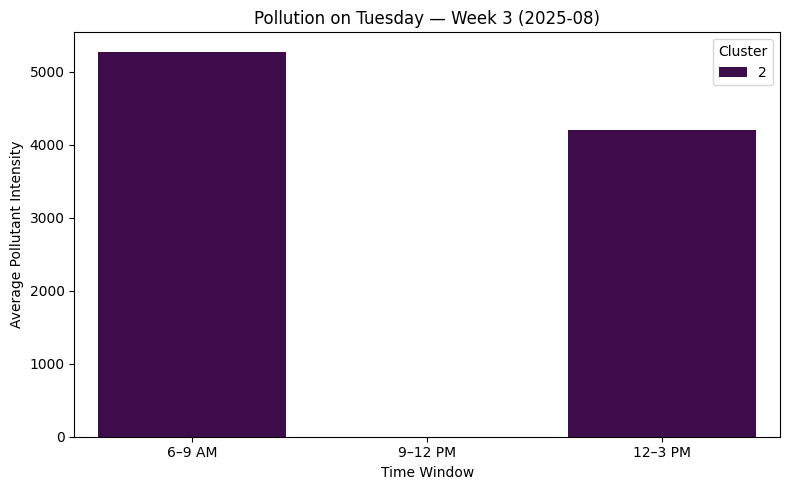

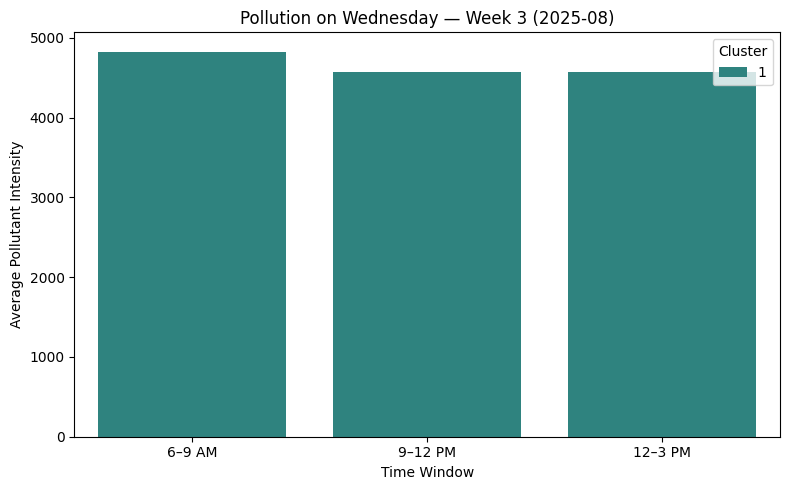

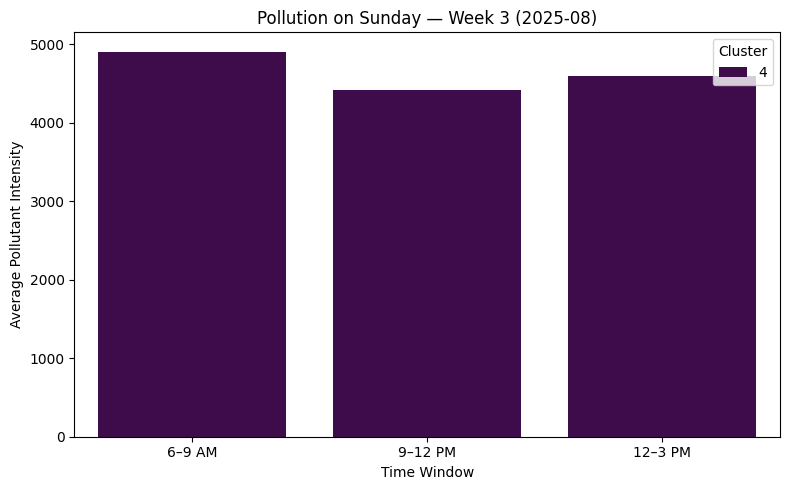

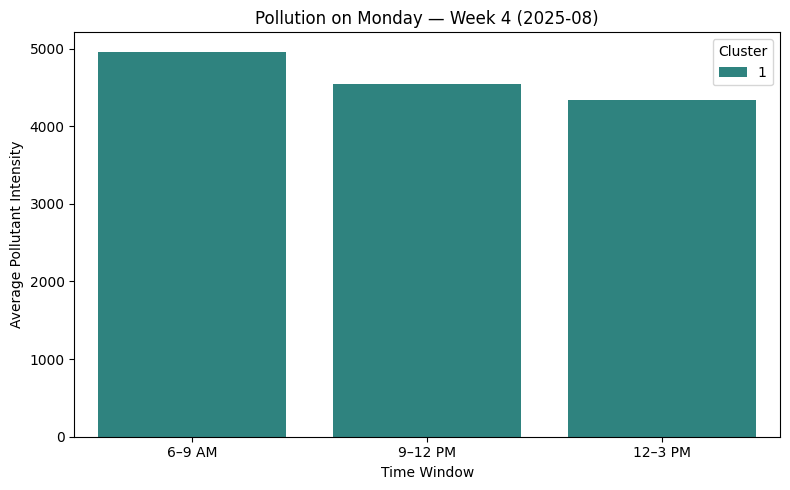

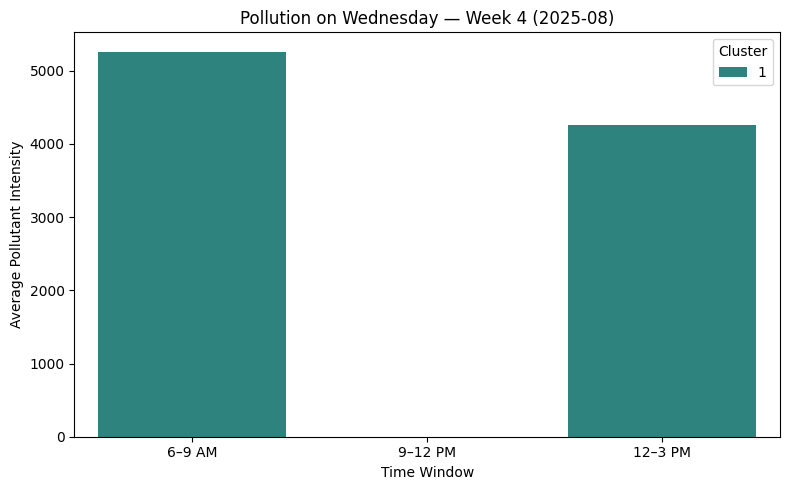

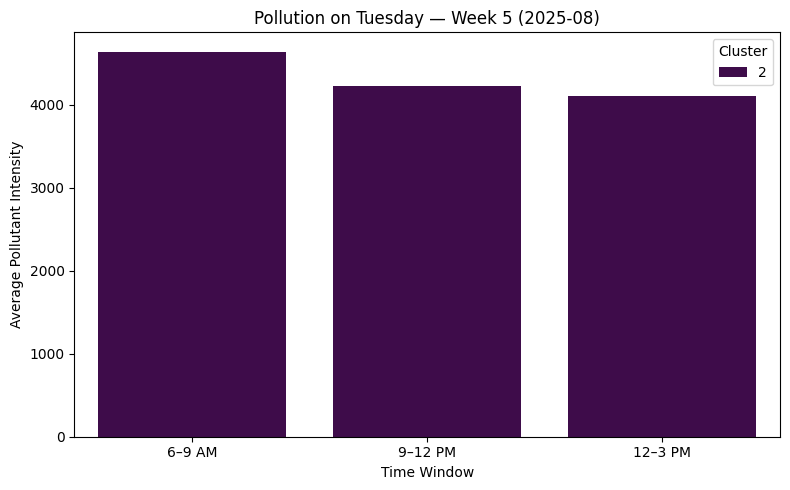

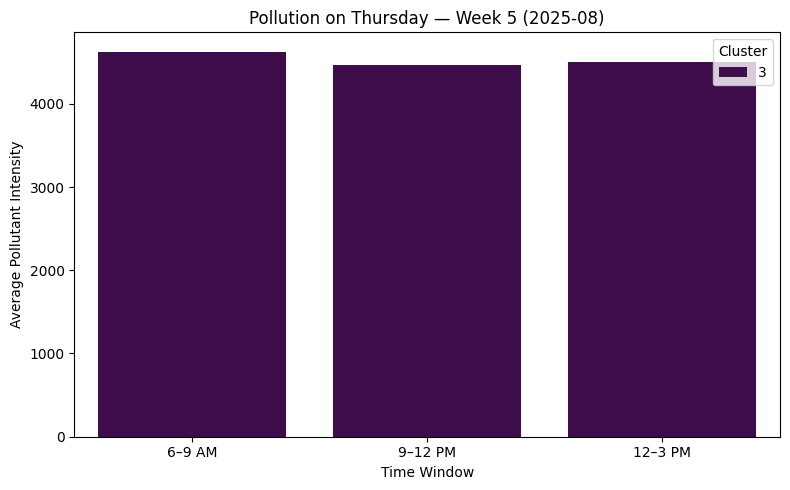

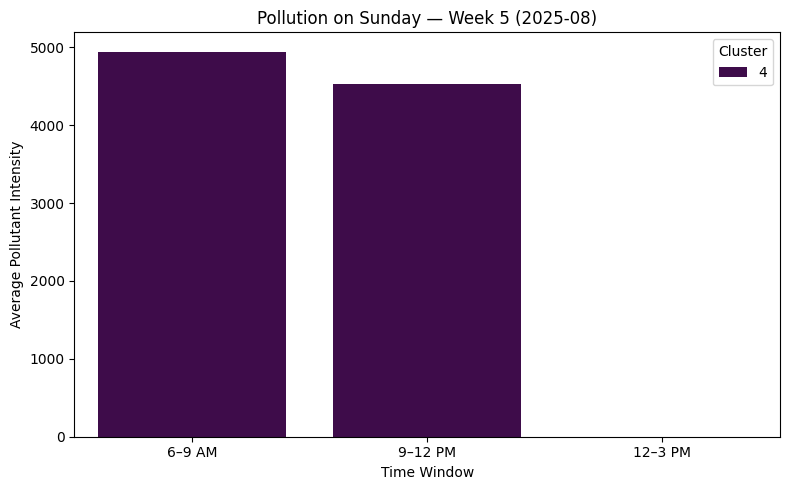


 Month: 2025-09


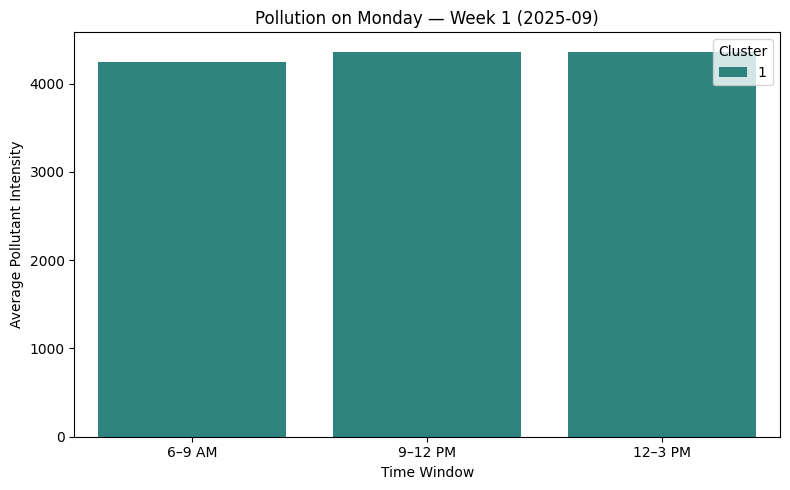

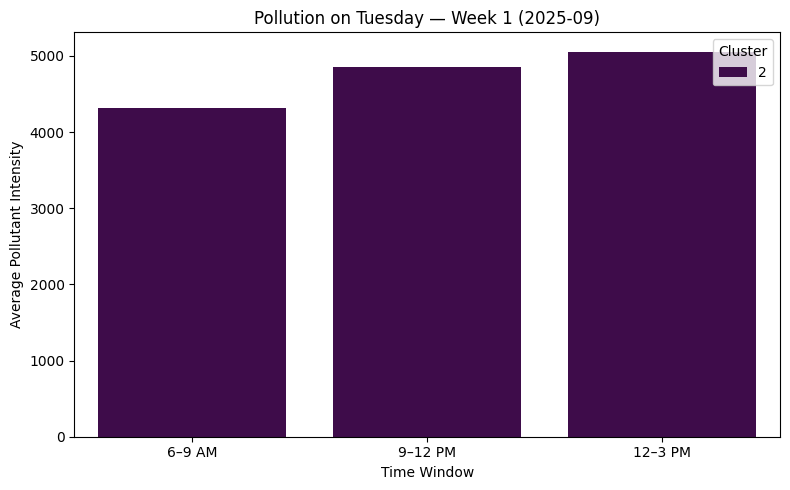

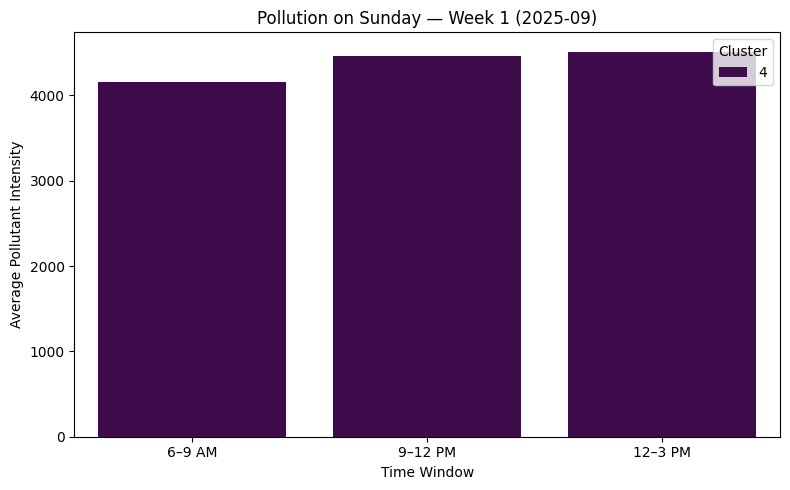

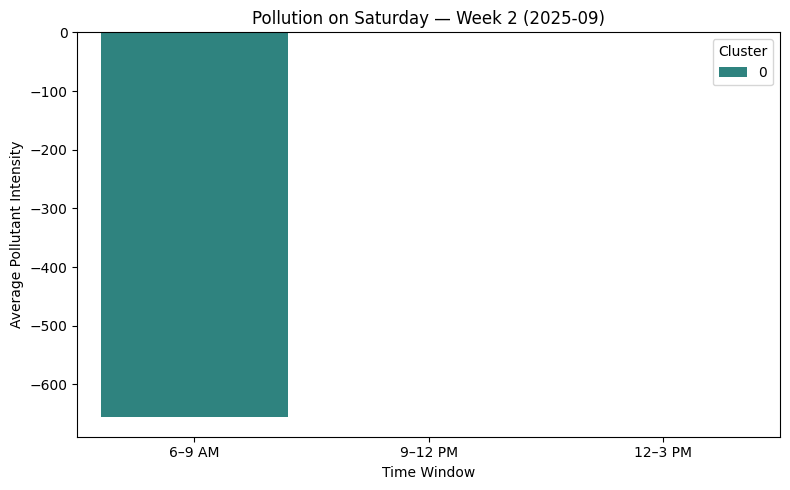

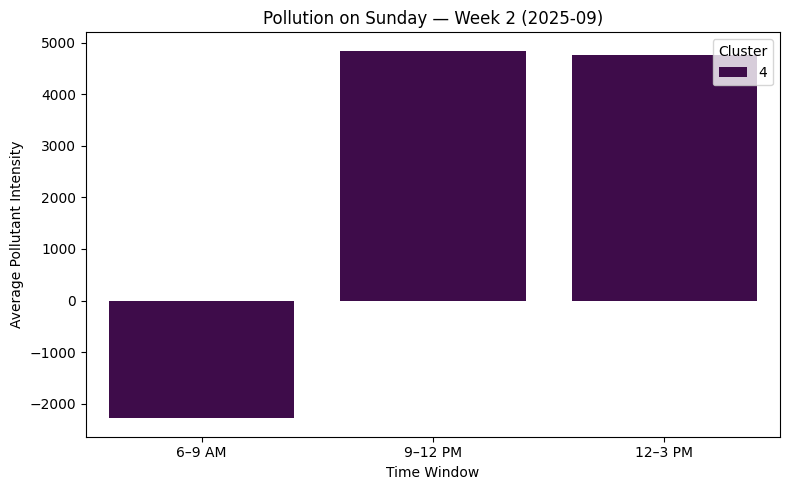

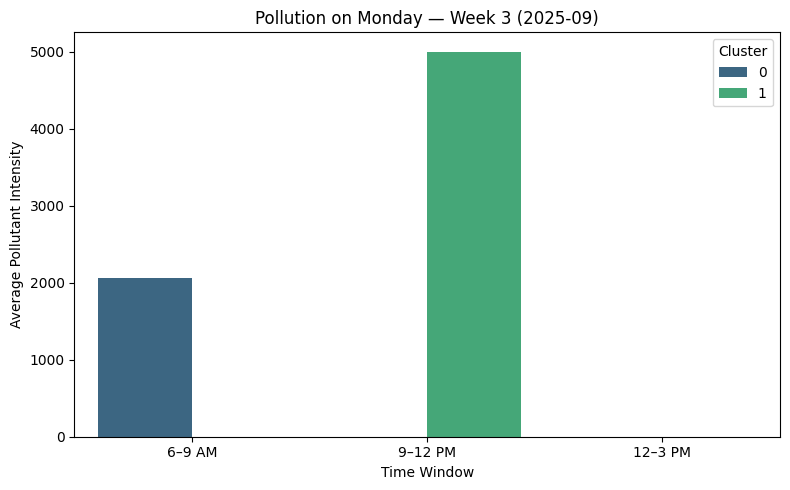

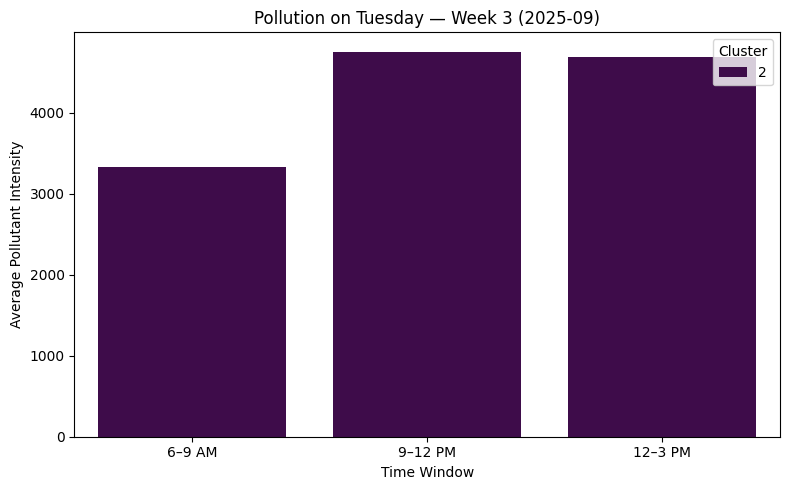

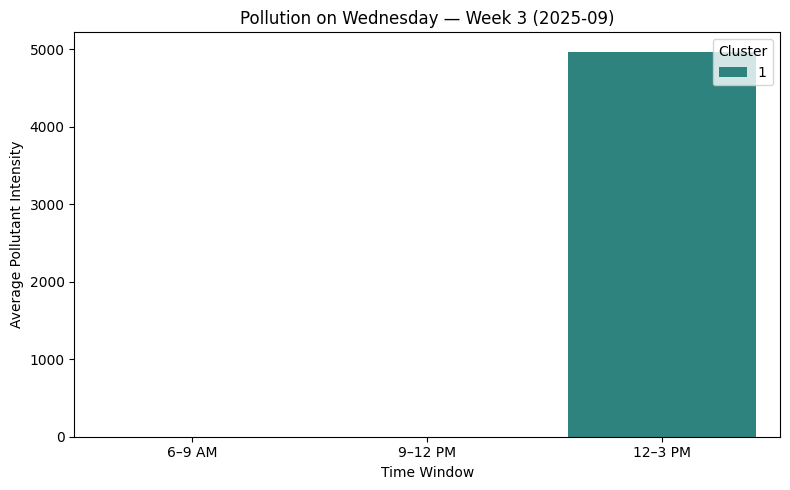

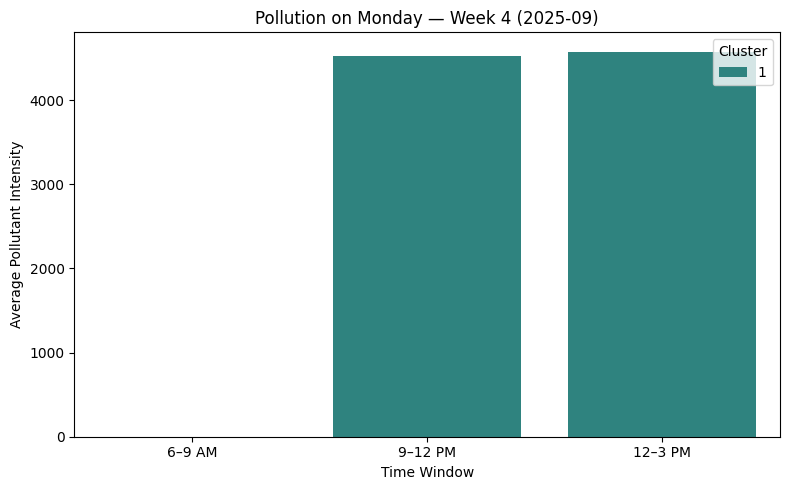

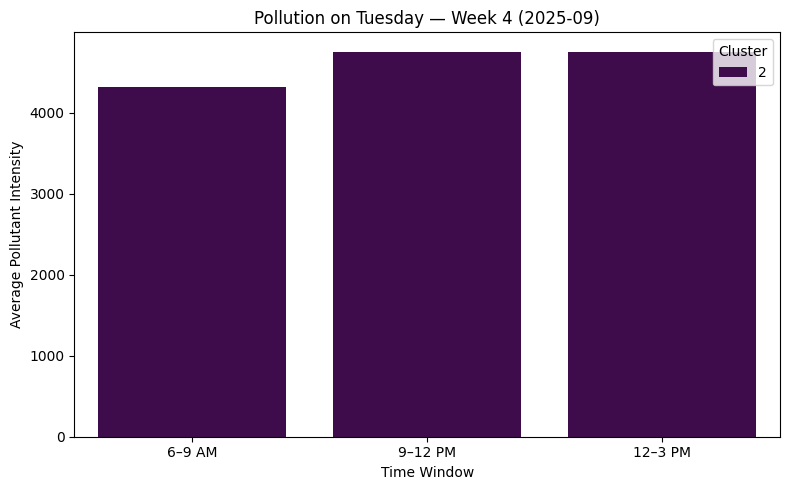

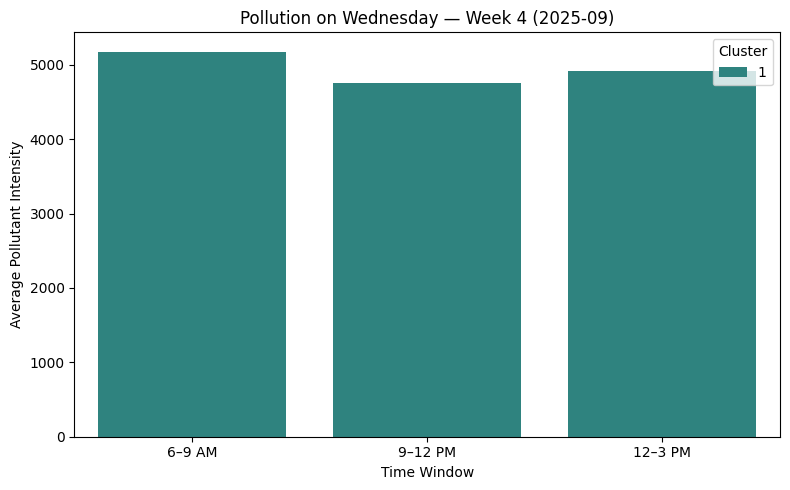

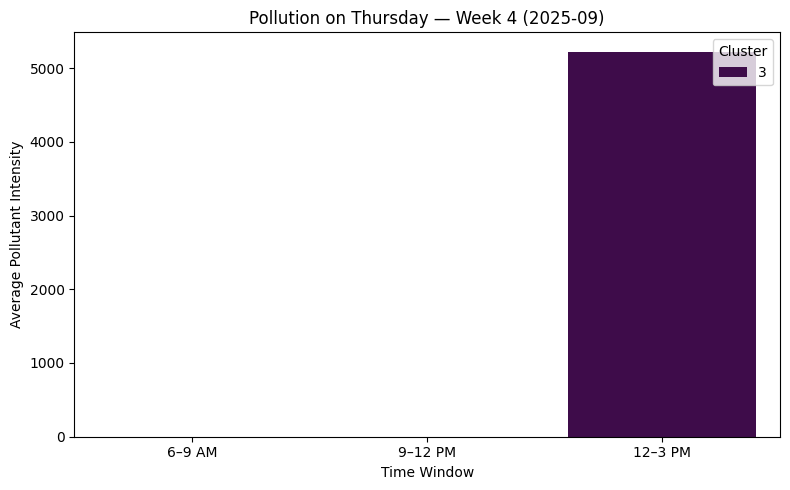

In [ ]:
time_order = ["6–9 AM", "9–12 PM", "12–3 PM"]

for month in agg_df['month'].unique():
    month_data = agg_df[agg_df['month'] == month]
    weeks = sorted(month_data['week_in_month'].unique())

    print(f"\n Month: {month}")

    for week in weeks:
        week_data = month_data[month_data['week_in_month'] == week]
        days = week_data['day_name'].unique()

        for day in sorted(days, key=lambda d: ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'].index(d)):
            day_data = week_data[week_data['day_name'] == day]

            # Sort time windows chronologically
            day_data = day_data.copy()
            day_data['time_window'] = pd.Categorical(day_data['time_window'], categories=time_order, ordered=True)
            day_data = day_data.sort_values('time_window')

            plt.figure(figsize=(8,5))
            sns.barplot(
                data=day_data,
                x='time_window',
                y=day_data[pollutant_cols].mean(axis=1),
                hue='Cluster',
                palette='viridis'
            )
            plt.title(f"Pollution on {day} — Week {int(week)} ({month})")
            plt.xlabel("Time Window")
            plt.ylabel("Average Pollutant Intensity")
            plt.legend(title="Cluster", loc="upper right")
            plt.tight_layout()
            plt.show()


In [ ]:
# --- 1️⃣1️⃣ Optional summary table ---
summary = (
    agg_df.groupby(['month', 'Cluster'])
    [pollutant_cols].mean()
    .round(3)
)
print("\n📊 Monthly Temporal Cluster Summary:\n")
display(summary)


📊 Monthly Temporal Cluster Summary:



carbondioxide  carbonmonoxide       dust  outlier   PCA1  \
month   Cluster                                                             
2025-04 0              641.387          42.213 -22528.001      1.0 -0.833   
        1              646.304          38.462  24436.807      1.0  0.565   
        2              648.179          39.772   9742.289      1.0  0.118   
        3              654.110          39.820 -16021.717      1.0 -0.514   
        4              635.837          40.061 -18279.671      1.0 -0.587   
2025-05 0              645.771          46.601 -13750.897      1.0 -0.910   
        1              647.385          42.475  27829.517      1.0  0.381   
        2              629.891          44.264  17315.611      1.0  0.004   
        3              645.347          44.487  14233.353      1.0 -0.085   
        4              646.302          44.003  -3692.752      1.0 -0.491   
2025-06 0              643.536          44.150  12417.663      1.0 -0.107   
        1              643.769          37.950  26434.873      1.0  0.647   
        2              654.770          33.559  25001.515      1.0  0.905   
        3              638.803          42.649  25838.906      1.0  0.320   
        4              649.949          43.051  10601.898      1.0 -0.078   
2025-07 0              650.708          58.337  28033.596      1.0 -0.667   
        1              651.011          29.686  26786.334      1.0  1.205   
        2              643.715          34.729  26926.521      1.0  0.873   
        3              652.711          44.620  25625.821      1.0  0.185   
        4              696.000          24.486 -29982.514      1.0  0.165   
2025-08 0              674.839          49.831  24522.093      1.0 -0.186   
        1              651.823          35.494  26576.327      1.0  0.814   
        2              622.421          37.770  27050.991      1.0  0.673   
        3              648.711          37.911  26806.043      1.0  0.659   
        4              635.049          40.170  25390.612      1.0  0.474   
2025-09 0              652.865          44.328   3507.204      1.0 -0.336   
        1              651.616          35.401  27435.242      1.0  0.842   
        2              652.169          44.199  26513.194      1.0  0.235   
        3              953.500          42.000  30340.500      1.0  0.498   
        4              648.674          47.842  19760.436      1.0 -0.172   

                  PCA2  
month   Cluster         
2025-04 0       -0.038  
        1       -0.017  
        2       -0.007  
        3        0.020  
        4       -0.069  
2025-05 0       -0.005  
        1       -0.002  
        2       -0.084  
        3       -0.009  
        4       -0.007  
2025-06 0       -0.018  
        1       -0.031  
        2        0.013  
        3       -0.044  
        4        0.010  
2025-07 0        0.053  
        1       -0.015  
        2       -0.038  
        3        0.029  
        4        0.186  
2025-08 0        0.150  
        1        0.003  
        2       -0.135  
        3       -0.006  
        4       -0.068  
2025-09 0        0.027  
        1        0.002  
        2        0.026  
        3        1.496  
        4        0.016


 Monthly Cluster & Pollution Summary:



,Dominant_Cluster,Dominant_Cluster_%,Peak_Pollution_Hour,Avg_carbondioxide,Avg_carbonmonoxide,Avg_dust
month,,,,,,
2025-04,4,32.22,14,642.258,40.352,-6587.917
2025-05,1,37.58,6,643.173,44.215,12792.872
2025-06,1,46.44,7,644.700,39.806,21989.418
2025-07,1,48.98,6,646.528,33.750,26365.238
2025-08,1,50.27,6,645.993,36.601,26288.716
2025-09,1,47.12,14,649.443,41.376,24170.290


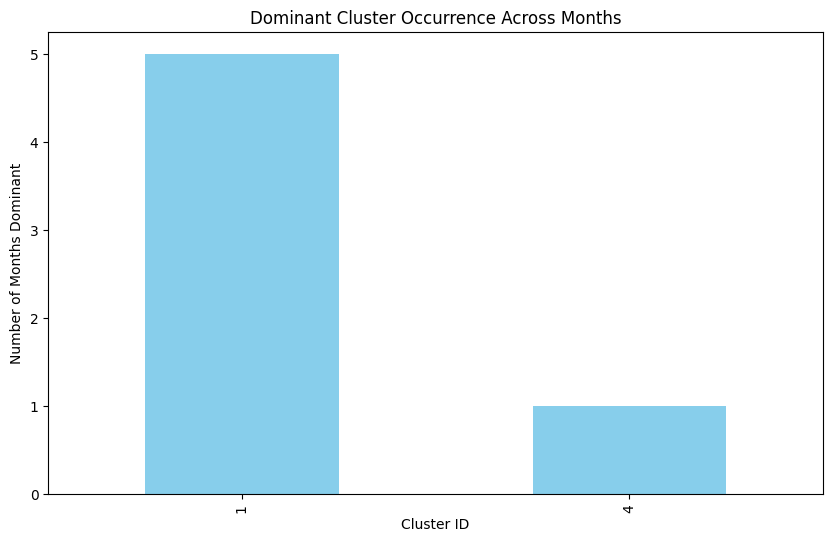

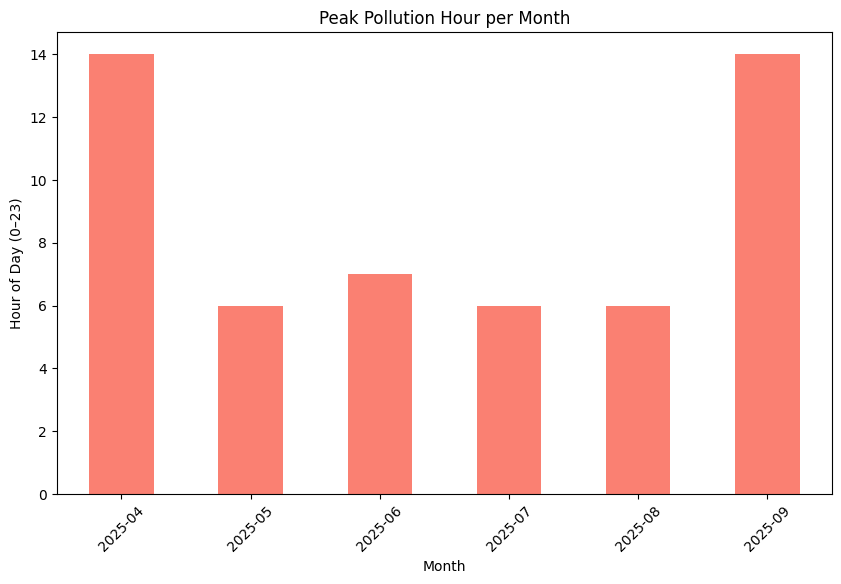

In [ ]:
# Monthly cluster frequency summary
monthly_cluster_counts = (
    df_clean.groupby(['month', 'Cluster'])
    .size()
    .unstack(fill_value=0)
)

monthly_cluster_freq = monthly_cluster_counts.div(monthly_cluster_counts.sum(axis=1), axis=0) * 100

# Monthly average pollution levels
# Corrected: Filter to include only numeric pollutant columns.
pollutant_cols = ['carbondioxide', 'carbonmonoxide', 'dust'] # Use the original pollutant list from the problem context

monthly_pollution_mean = df_clean.groupby('month')[pollutant_cols].mean()

# Peak pollution hour per month
# Corrected: Use df_clean instead of df_pollutants, as df_clean has 'month' and 'hour' columns.
monthly_peak_hour = (
    df_clean.groupby(['month', 'hour']) # Changed df_pollutants to df_clean
    .size()
    .groupby('month')
    .idxmax()
)

# Combining all results
summary_table = pd.DataFrame({
    'Dominant_Cluster': monthly_cluster_counts.idxmax(axis=1),
    'Dominant_Cluster_%': monthly_cluster_freq.max(axis=1).round(2),
    'Peak_Pollution_Hour': monthly_peak_hour.map(lambda x: x[1]),
})

# Add average pollution columns
for col in pollutant_cols:
    summary_table[f'Avg_{col}'] = monthly_pollution_mean[col].round(3)

print("\n Monthly Cluster & Pollution Summary:\n")
display(summary_table)

# Dominant cluster trend over months
plt.figure(figsize=(10,6))
summary_table['Dominant_Cluster'].astype(str).value_counts().plot(kind='bar', color='skyblue')
plt.title("Dominant Cluster Occurrence Across Months")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Months Dominant")
plt.show()

# Peak pollution hours
plt.figure(figsize=(10,6))
summary_table['Peak_Pollution_Hour'].plot(kind='bar', color='salmon')
plt.title("Peak Pollution Hour per Month")
plt.xlabel("Month")
plt.ylabel("Hour of Day (0–23)")
plt.xticks(rotation=45)
plt.show()

## 14. Observations per cluster per month

Cluster,0,1,2,3,4
month,,,,,
2025-04,1097,1254,1700,58,1953
2025-05,3164,3564,1298,19,1438
2025-06,3171,3577,425,46,483
2025-07,2150,2443,91,183,121
2025-08,2677,3002,68,132,93
2025-09,1313,1467,112,95,126


<Axes: xlabel='month'>

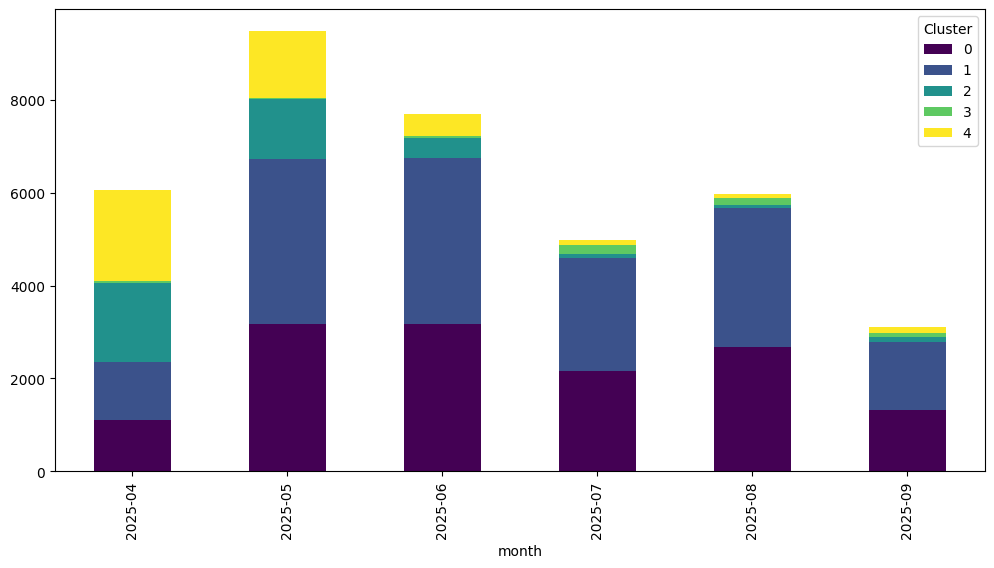

In [ ]:
df_clean['month'] = df_clean['updated_at'].dt.to_period('M')
monthly_counts = df_clean.groupby(['month', 'Cluster']).size().unstack(fill_value=0)
display(monthly_counts)
monthly_counts.plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')

## 15. Displaying final results

In [ ]:
print("\n Final Air Quality Cluster Severity Summary:")
final_summary = cluster_summary.copy()
final_summary['Pollution_Score'] = pollution_scores
final_summary['Severity_Label'] = final_summary.index.map(severity_labels)
display(final_summary)


 Final Air Quality Cluster Severity Summary:


,carbondioxide,carbonmonoxide,dust,Pollution_Score,Severity_Label
Cluster,,,,,
0,835.162643,38.582880,29400.284454,10091.343326,Hazardous
1,481.378072,38.692851,29416.269528,9978.780150,Polluted
2,833.034555,41.996022,-30812.227280,-9979.065568,Moderate Air Quality
3,655.665588,85.295188,21436.997574,7392.652783,Poor Air Quality
4,475.133124,41.789580,-30854.855210,-10112.644169,Clean Air


## 16. Evaluating Cluster Quality

In [ ]:
# Assuming pollutant_cols is correctly defined as ['carbondioxide', 'carbonmonoxide', 'dust']
# Re-scale the relevant features from df_clean for evaluation of the initial clustering
scaler_eval = StandardScaler()
X_scaled_eval = scaler_eval.fit_transform(df_clean[pollutant_cols])

sil_score = silhouette_score(X_scaled_eval, df_clean['Cluster'])
print(f"Silhouette Score: {sil_score:.3f}")

dbi = davies_bouldin_score(X_scaled_eval, df_clean['Cluster'])
print(f"Davies–Bouldin Index: {dbi:.3f}")

ch_score = calinski_harabasz_score(X_scaled_eval, df_clean['Cluster'])
print(f"Calinski–Harabasz Score: {ch_score:.3f}")

Silhouette Score: 0.432
Davies–Bouldin Index: 0.803
Calinski–Harabasz Score: 22147.474
